In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost 
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix, classification_report, 
)
from sklearn.naive_bayes import MultinomialNB

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


In [2]:

df = pd.read_csv('Copia de data_merged.csv')



In [3]:

def aux(temp):
    if temp<=80:
        return 'lento'
    elif temp <=120:
        return 'moderado'
    return 'rapido'

df['duration_ms']= df['duration_ms']/60000
df['duration_ms_ar'] = df['duration_ms_ar']/60000
df['duration_ms_yr'] = df['duration_ms_yr']/60000

df['energy_ratio_yr'] = df['energy_yr']*df['acousticness_yr']
df['electro_focus_yr'] = (1-df['acousticness_yr'])*df['energy_yr']*df['instrumentalness_yr']
df['vocal_energy_yr'] = (1-df['instrumentalness_yr'])*df['energy_yr']

df['energy_ratio_'] = df['energy']*df['acousticness']
df['electro_focus'] = (1-df['acousticness'])*df['energy']*df['instrumentalness']
df['vocal_energy'] = (1-df['instrumentalness'])*df['energy']

df['energy_ratio_ar'] = df['energy_ar']*df['acousticness_ar']
df['electro_focus_ar'] = (1-df['acousticness_ar'])*df['energy_ar']*df['instrumentalness_ar']
df['vocal_energy_ar'] = (1-df['instrumentalness_ar'])*df['energy_ar']


df['temp_range'] = df['tempo_yr'].apply(aux)
df = pd.get_dummies(df,columns=['temp_range'],prefix='temp')
df[['temp_moderado','temp_rapido']] = df[['temp_moderado','temp_rapido']].astype(int)

In [4]:
df

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,electro_focus_yr,vocal_energy_yr,energy_ratio_,electro_focus,vocal_energy,energy_ratio_ar,electro_focus_ar,vocal_energy_ar,temp_moderado,temp_rapido
0,0.013100,0.2560,3.039117,0.895,0,0.000106,0.0821,-4.860,29,0.0707,...,0.037649,0.495522,0.011725,0.000094,0.894905,0.105519,1.463051e-02,0.709725,0,1
1,0.980000,0.2770,3.449533,0.145,0,0.879000,0.1110,-19.898,0,0.0845,...,0.009108,0.183282,0.142100,0.002549,0.017545,0.208915,4.504740e-03,0.097838,1,0
2,0.795000,0.6850,5.244450,0.483,0,0.878000,0.1130,-10.202,1,0.0337,...,0.010180,0.186780,0.383985,0.086935,0.058926,0.491828,6.804020e-02,0.059278,1,0
3,0.656000,0.7880,2.995783,0.808,0,0.000000,0.1540,-6.590,0,0.0395,...,0.010180,0.186780,0.530048,0.000000,0.808000,0.537642,2.723306e-07,0.744999,1,0
4,0.302000,0.0753,8.309333,0.150,0,0.884000,0.1210,-16.705,0,0.0371,...,0.007777,0.179243,0.045300,0.092555,0.017400,0.253033,3.753181e-02,0.103445,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172225,0.000067,0.5670,0.616667,0.862,0,0.875000,0.4810,-5.617,0,0.0670,...,0.116161,0.507938,0.000058,0.754199,0.107750,0.000040,5.311705e-01,0.370306,0,1
172226,0.000994,0.3960,8.363733,0.979,0,0.609000,0.1360,-9.138,0,0.0878,...,0.133639,0.491948,0.000973,0.595618,0.382789,0.016665,1.873520e-01,0.759704,0,1
172227,0.864000,0.6380,2.692667,0.156,0,0.000000,0.1830,-17.372,20,0.0741,...,0.013051,0.250225,0.134784,0.000000,0.156000,0.131158,2.533831e-04,0.142178,1,0
172228,0.029900,0.5330,5.713783,0.547,0,0.011300,0.0723,-9.290,35,0.0326,...,0.031967,0.443442,0.016355,0.005996,0.540819,0.098186,1.820001e-02,0.678454,1,0


In [5]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

def categorize_popularity(popularity):
    if popularity<=20:
        return 0 # baja
    elif popularity <=45:
        return 1 # media
    return 2 # alta
    

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (Baja): 73762 (42.8%)
   1 (Media): 62074 (36.0%)
   2 (Alta): 36394 (21.1%)


<Axes: xlabel='popularity_multiclass'>

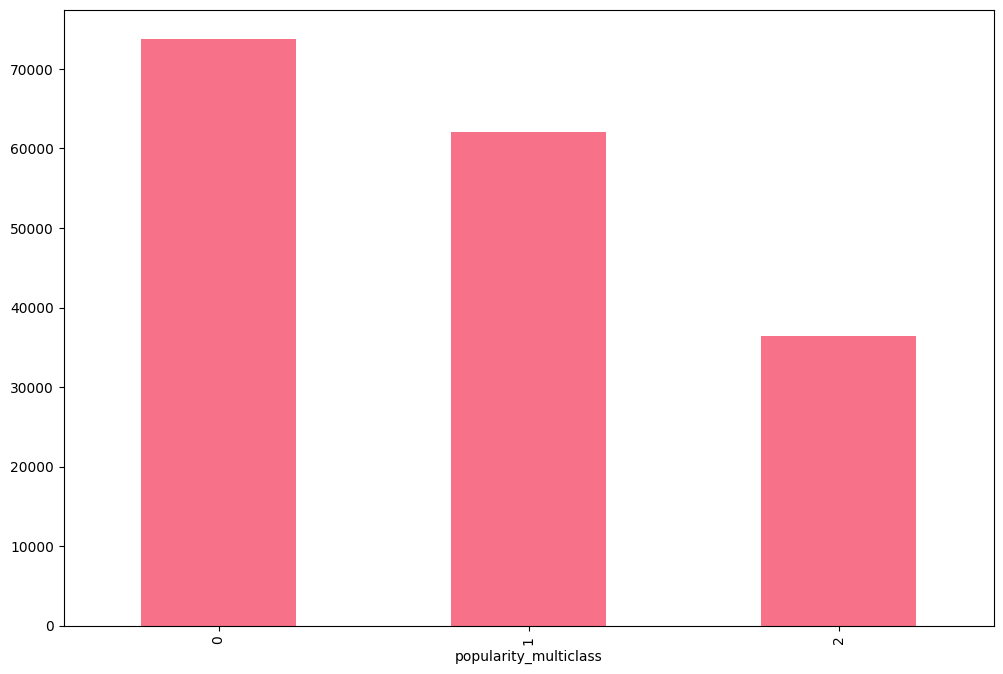

In [20]:
df_processed['popularity_multiclass'].value_counts().plot(kind='bar')

In [6]:


_X = df_processed.copy()

X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity_multiclass'] 



In [22]:
df_processed.groupby('popularity_multiclass')['popularity'].describe()

,count,mean,std,min,25%,50%,75%,max
popularity_multiclass,,,,,,,,
0,73762.0,4.438369,6.348734,0.0,0.0,0.0,8.0,20.0
1,62074.0,32.917051,6.956338,21.0,27.0,33.0,39.0,45.0
2,36394.0,57.551904,8.900427,46.0,50.0,56.0,63.0,100.0


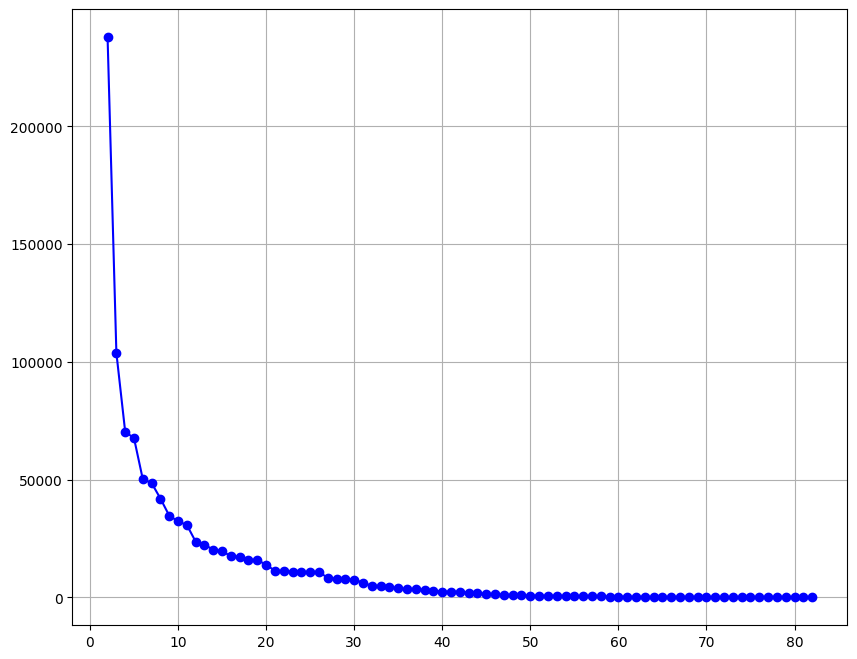

In [23]:

selector = SelectKBest(score_func=f_classif,k='all')
X_new = selector.fit_transform(X,y_multiclass_3)
total_score = selector.scores_
sorted_scoress = np.sort(total_score)[::-1]
plt.figure(figsize=(10,8))
plt.grid(visible=True)
plt.plot(range(1,X.shape[1]+1),sorted_scoress,'bo-')


In [24]:
selector = SelectKBest(score_func=f_classif,k=6)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select


array(['popularity_ar', 'acousticness_yr', 'energy_yr',
       'instrumentalness_yr', 'popularity_yr', 'vocal_energy_yr'],
      dtype=object)

In [25]:
_X=X.copy()
y =y_multiclass_3

In [26]:
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)


In [27]:
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
smote = SMOTE(sampling_strategy='auto')
X_train_reduce,y_train_reduce = smote.fit_resample(X_train_reduce,y_train_reduce)

Fitting 5 folds for each of 4 candidates, totalling 20 fits

RandomForest
Best params: {'max_depth': None, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     14752
           1       0.78      0.84      0.81     12415
           2       0.82      0.70      0.76      7279

    accuracy                           0.85     34446
   macro avg       0.84      0.83      0.83     34446
weighted avg       0.85      0.85      0.85     34446



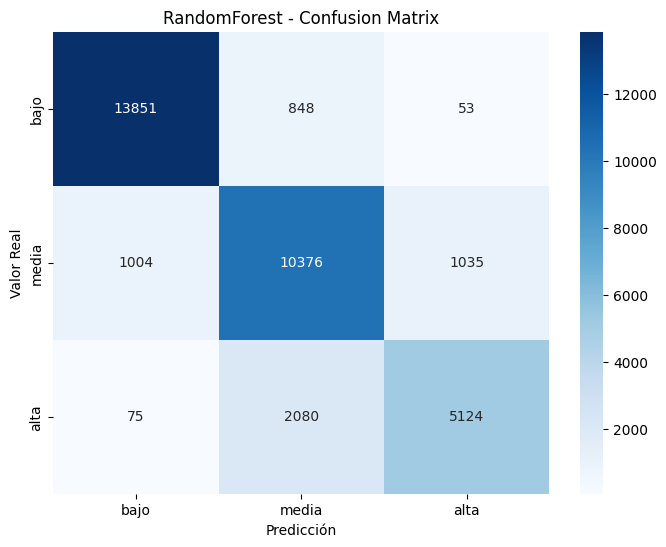


random
              precision    recall  f1-score   support

           0       0.42      0.33      0.37     14752
           1       0.35      0.33      0.34     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.35      0.33      0.33     34446



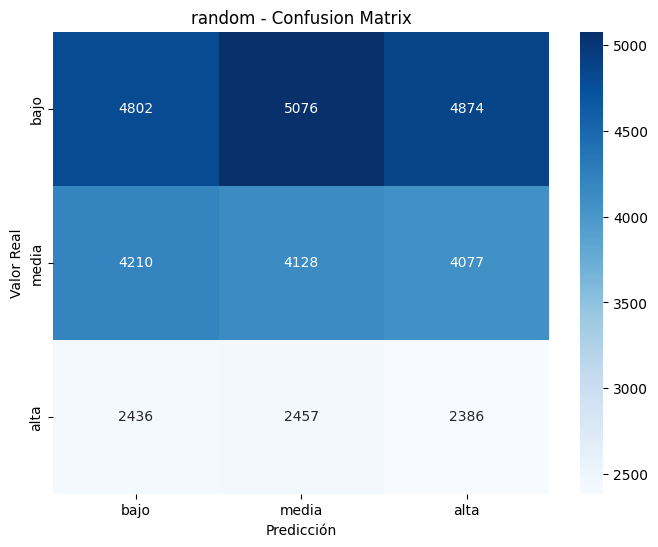

[1.43680150e-02 1.38248276e-02 1.56218459e-02 1.31806420e-02
 1.84879867e-03 1.23597793e-02 1.45727154e-02 1.60275480e-02
 1.41857048e-02 1.34268003e-02 1.32428258e-02 5.89707874e-02
 2.22383650e-03 1.51298359e-03 2.00116753e-03 1.02307431e-03
 1.82932288e-03 1.88724099e-03 1.16439815e-03 2.14789089e-03
 1.36412173e-03 2.00512410e-03 1.49352763e-03 1.26078300e-03
 2.15117594e-03 2.13350395e-03 1.34052792e-02 9.72074190e-03
 1.14752266e-02 1.25968613e-02 1.70860360e-02 1.01792407e-02
 1.31786082e-02 1.01667673e-02 9.06183692e-03 9.16960376e-03
 1.76684924e-01 1.34885348e-02 1.58483010e-03 8.59664177e-04
 1.29778446e-03 2.82447077e-04 9.22231043e-04 1.10712648e-03
 5.23647886e-04 1.58152372e-03 6.97105324e-04 1.57424833e-03
 9.03910513e-04 6.85809495e-04 1.02063149e-03 8.07134087e-04
 3.40777889e-02 1.43111700e-02 9.34934665e-03 3.83688810e-02
 2.03075497e-02 7.18847931e-03 4.10980202e-02 2.92345960e-02
 2.66605550e-02 1.59789341e-02 3.76485861e-02 0.00000000e+00
 1.22197282e-03 5.028537

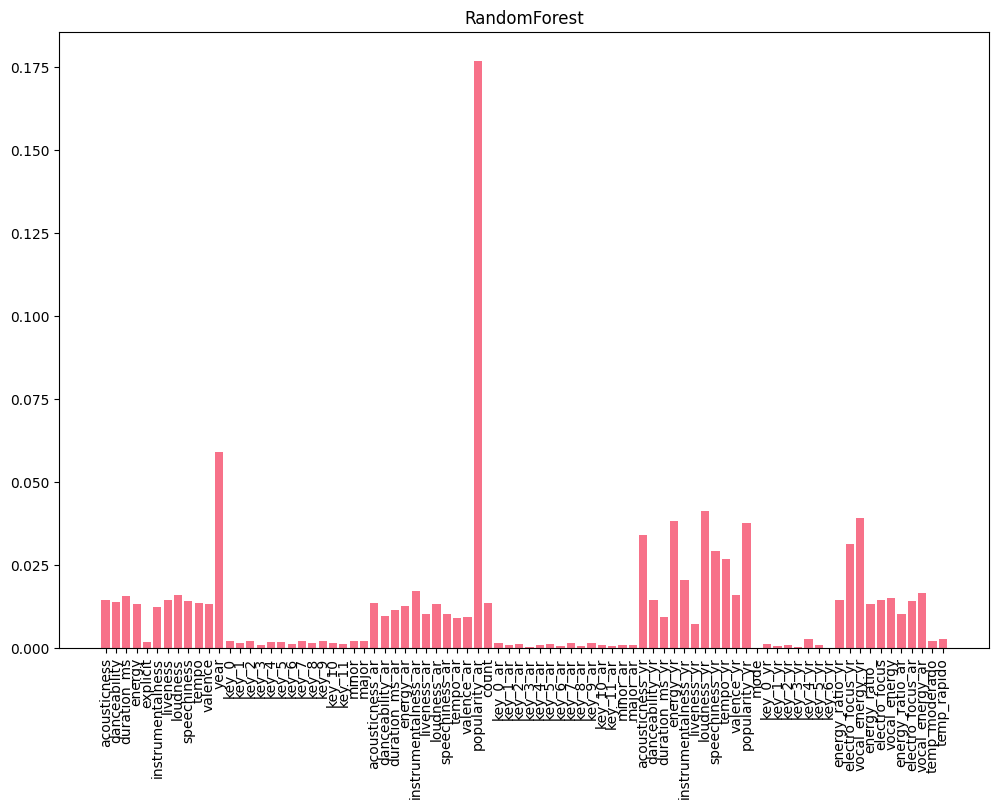

Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 300}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     14752
           1       0.78      0.84      0.81     12415
           2       0.83      0.70      0.76      7279

    accuracy                           0.85     34446
   macro avg       0.85      0.83      0.83     34446
weighted avg       0.85      0.85      0.85     34446



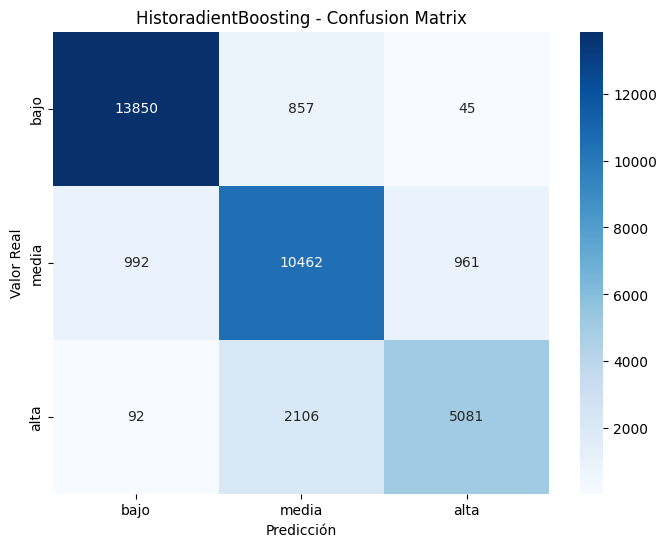


random
              precision    recall  f1-score   support

           0       0.44      0.34      0.38     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.34      0.26      7279

    accuracy                           0.34     34446
   macro avg       0.34      0.34      0.33     34446
weighted avg       0.36      0.34      0.34     34446



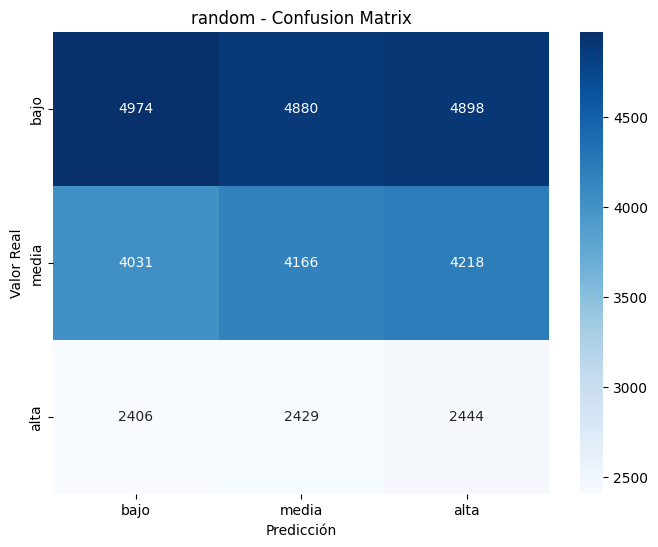

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     14752
           1       0.78      0.83      0.81     12415
           2       0.82      0.70      0.76      7279

    accuracy                           0.85     34446
   macro avg       0.84      0.83      0.83     34446
weighted avg       0.85      0.85      0.85     34446



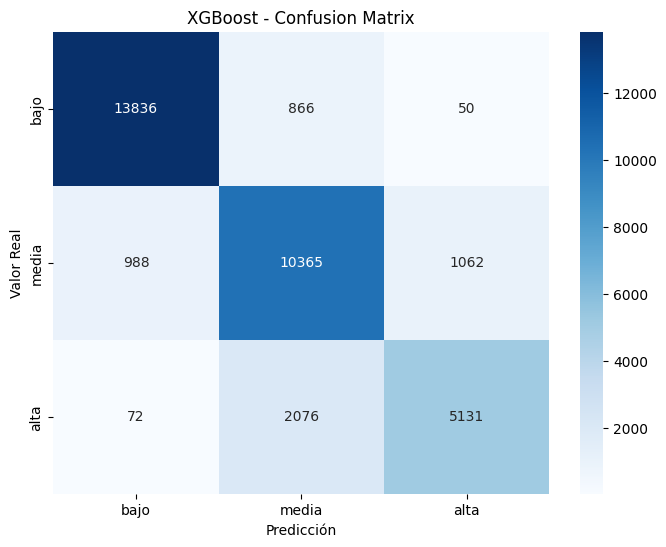


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.38     14752
           1       0.35      0.32      0.34     12415
           2       0.21      0.34      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.35      0.33      0.34     34446



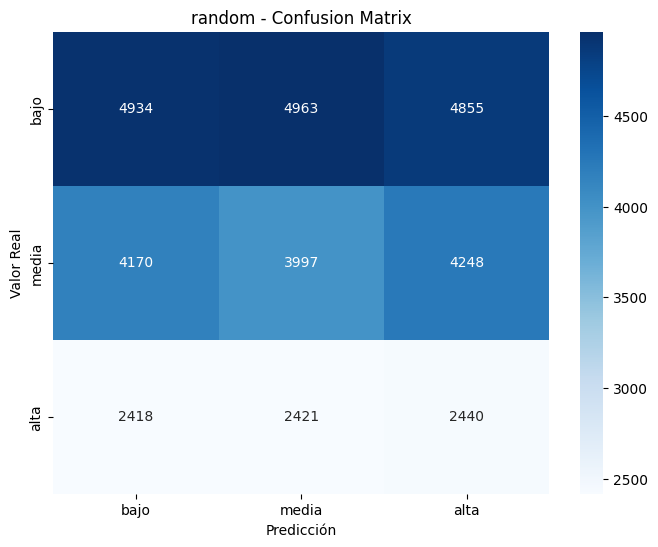

[0.00474774 0.00451832 0.00493425 0.00457082 0.006075   0.00456874
 0.00430105 0.0043234  0.0042944  0.00417175 0.0040627  0.02090969
 0.00749739 0.0081176  0.00683237 0.00660091 0.00880404 0.00757176
 0.0064841  0.00704484 0.0076596  0.00733649 0.00687624 0.00738275
 0.00498828 0.01389695 0.00544907 0.00495764 0.00476889 0.00487193
 0.00532774 0.0044871  0.004746   0.00448311 0.00470151 0.00421876
 0.26081407 0.00969979 0.00652125 0.00752398 0.00747442 0.00811626
 0.00813083 0.00730211 0.0059769  0.00860991 0.00791812 0.00739373
 0.00753578 0.00755861 0.00754372 0.00536106 0.05903248 0.00563576
 0.00986596 0.0114802  0.01741424 0.00523244 0.0076501  0.1126226
 0.00525018 0.00435133 0.03843984 0.         0.00588846 0.00652297
 0.00473859 0.00409008 0.00892754 0.00672597 0.00798762 0.00483227
 0.00451697 0.01353449 0.00391994 0.00385757 0.00378259 0.00422957
 0.0046245  0.00433219 0.01026773 0.02018236]


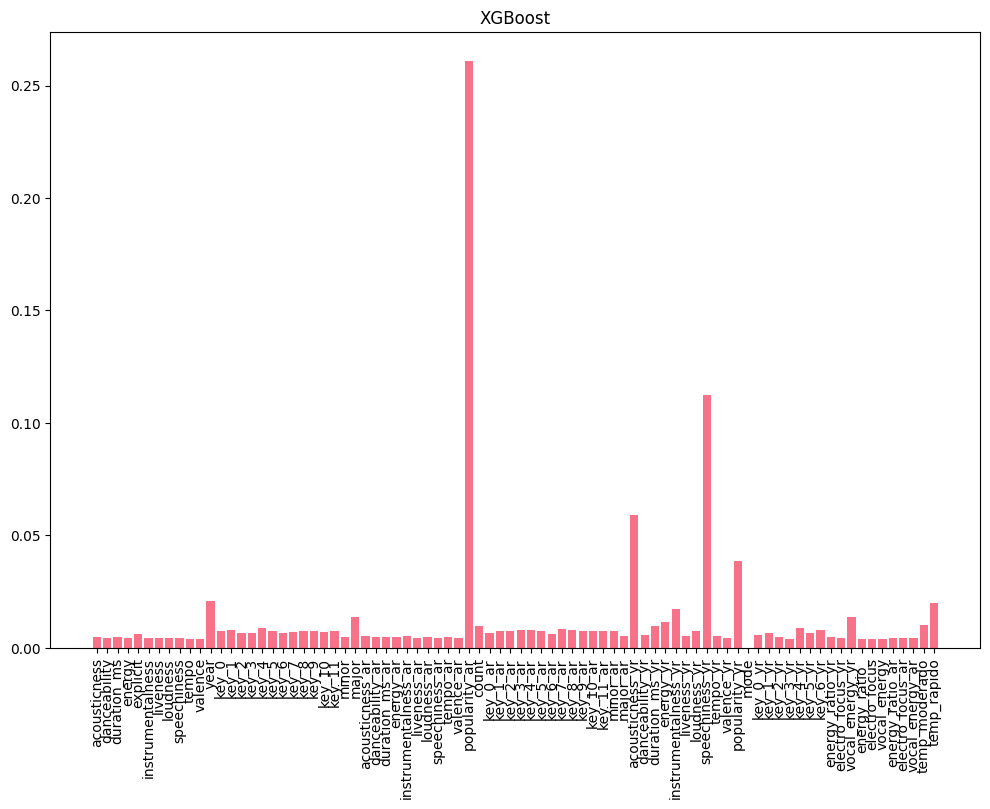

Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': None, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     14752
           1       0.77      0.83      0.80     12415
           2       0.82      0.68      0.74      7279

    accuracy                           0.84     34446
   macro avg       0.84      0.82      0.82     34446
weighted avg       0.85      0.84      0.84     34446



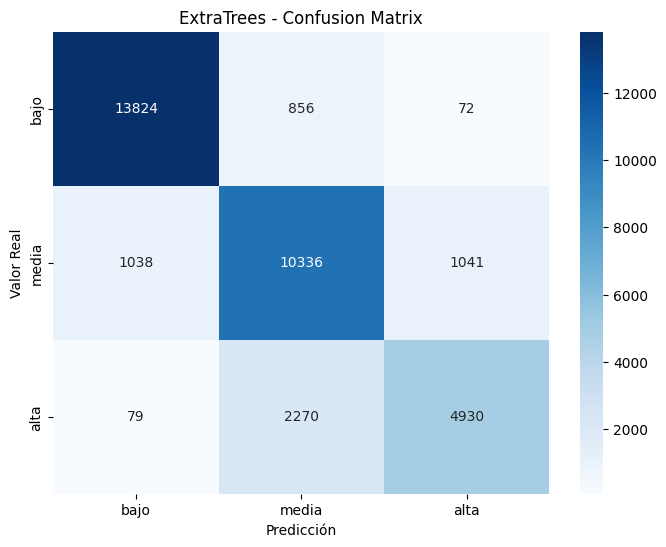


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



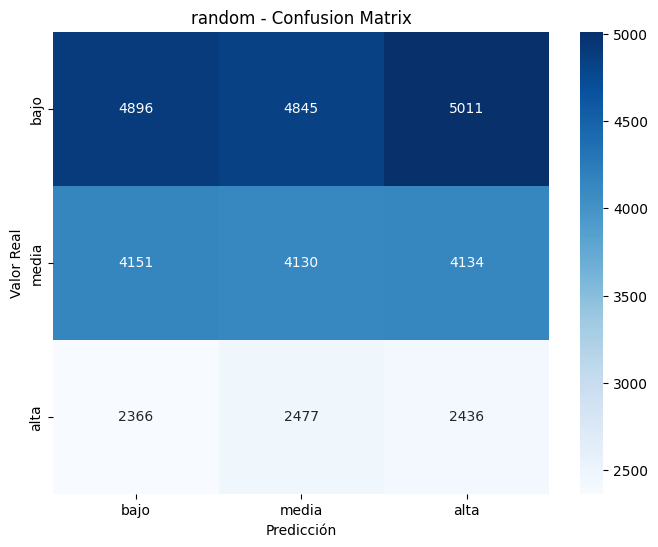

[1.87567105e-02 1.19696985e-02 1.18453165e-02 1.26644756e-02
 4.51252185e-03 1.47248693e-02 1.24670784e-02 1.29270470e-02
 1.19666187e-02 1.12401944e-02 1.15774459e-02 4.05715489e-02
 5.13095736e-03 3.48047119e-03 4.69231266e-03 2.44048721e-03
 3.96852624e-03 4.34774937e-03 2.71036838e-03 5.01568114e-03
 3.22117177e-03 4.63161782e-03 3.54915122e-03 2.99649665e-03
 4.98189313e-03 4.98847047e-03 2.05465361e-02 9.06593495e-03
 8.98908710e-03 1.20468647e-02 1.67355945e-02 9.39557854e-03
 1.11990334e-02 9.47014286e-03 8.11041225e-03 8.70601128e-03
 1.36047014e-01 1.32029305e-02 4.73301526e-03 2.62183843e-03
 3.95694292e-03 8.88903633e-04 2.89883648e-03 3.26924693e-03
 1.62529015e-03 4.73225751e-03 2.13132620e-03 4.66271376e-03
 2.54566793e-03 2.06473957e-03 3.02990798e-03 2.41701487e-03
 3.48658076e-02 1.21614206e-02 1.28456774e-02 4.29001136e-02
 2.32485535e-02 7.59630276e-03 3.33421639e-02 1.92793100e-02
 2.26617998e-02 1.84467792e-02 4.24561483e-02 0.00000000e+00
 3.53151466e-03 1.930599

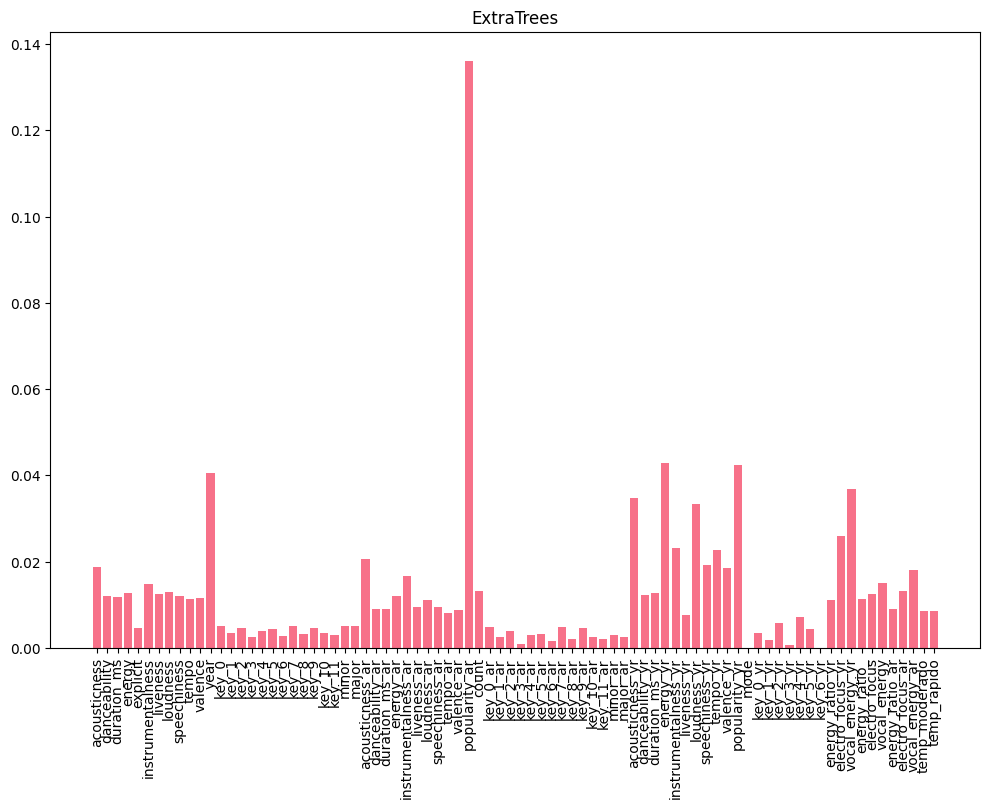

Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     14752
           1       0.78      0.77      0.78     12415
           2       0.75      0.75      0.75      7279

    accuracy                           0.83     34446
   macro avg       0.82      0.82      0.82     34446
weighted avg       0.83      0.83      0.83     34446



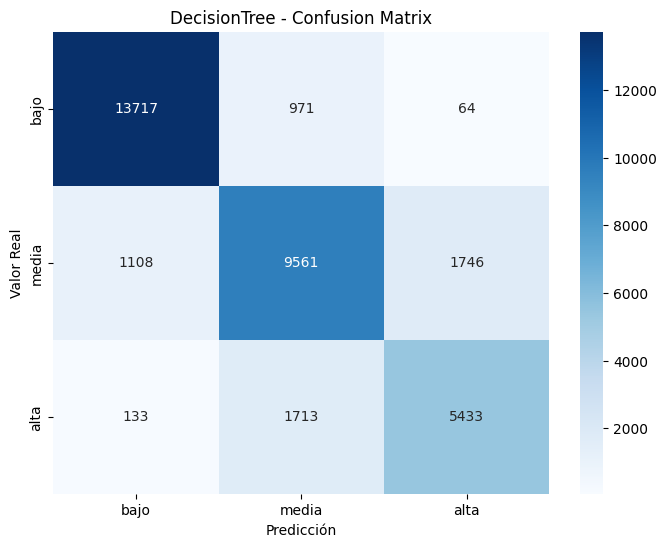


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.34      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



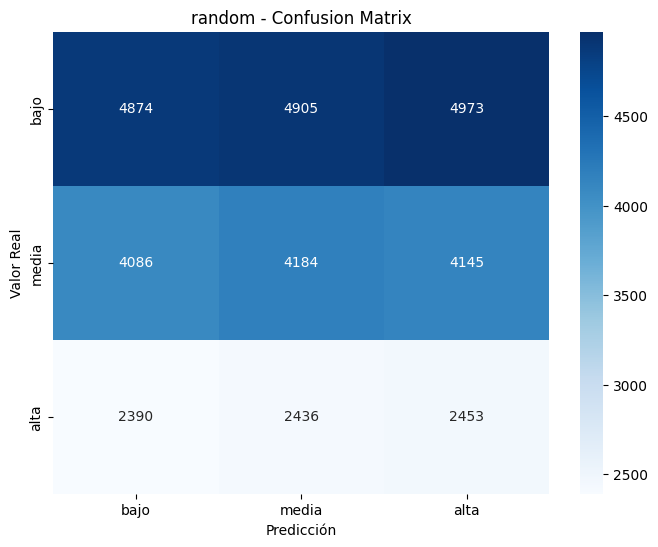

[9.34127572e-04 1.84664986e-03 3.00664347e-03 3.05606781e-04
 6.25906555e-05 3.96427120e-04 2.39006831e-03 9.96214125e-04
 1.64053108e-03 8.73468030e-04 9.98222711e-04 2.56829639e-02
 0.00000000e+00 6.90099030e-05 0.00000000e+00 4.13761867e-05
 4.60181858e-05 8.58117780e-05 4.07070870e-05 2.28663267e-05
 9.42791546e-05 1.19808905e-05 1.18914052e-04 8.00984485e-05
 0.00000000e+00 6.05646973e-05 7.92610066e-04 1.52950389e-03
 1.77033170e-03 2.11651582e-04 1.47188177e-03 1.25961699e-03
 7.05288067e-04 8.81812230e-04 1.07279764e-03 2.13452750e-03
 8.38419535e-01 1.49314059e-02 5.43724870e-05 1.98055742e-04
 1.65636729e-04 2.34103763e-05 0.00000000e+00 0.00000000e+00
 1.05793747e-04 3.08484954e-04 9.19835041e-05 3.89987134e-04
 4.33201589e-04 4.40993443e-05 0.00000000e+00 0.00000000e+00
 1.14530848e-02 5.84747326e-04 5.15716460e-03 3.24142290e-04
 2.99221320e-02 1.74001418e-03 6.47878692e-04 2.59685604e-02
 2.02821087e-03 2.89742086e-04 5.38569788e-03 0.00000000e+00
 0.00000000e+00 0.000000

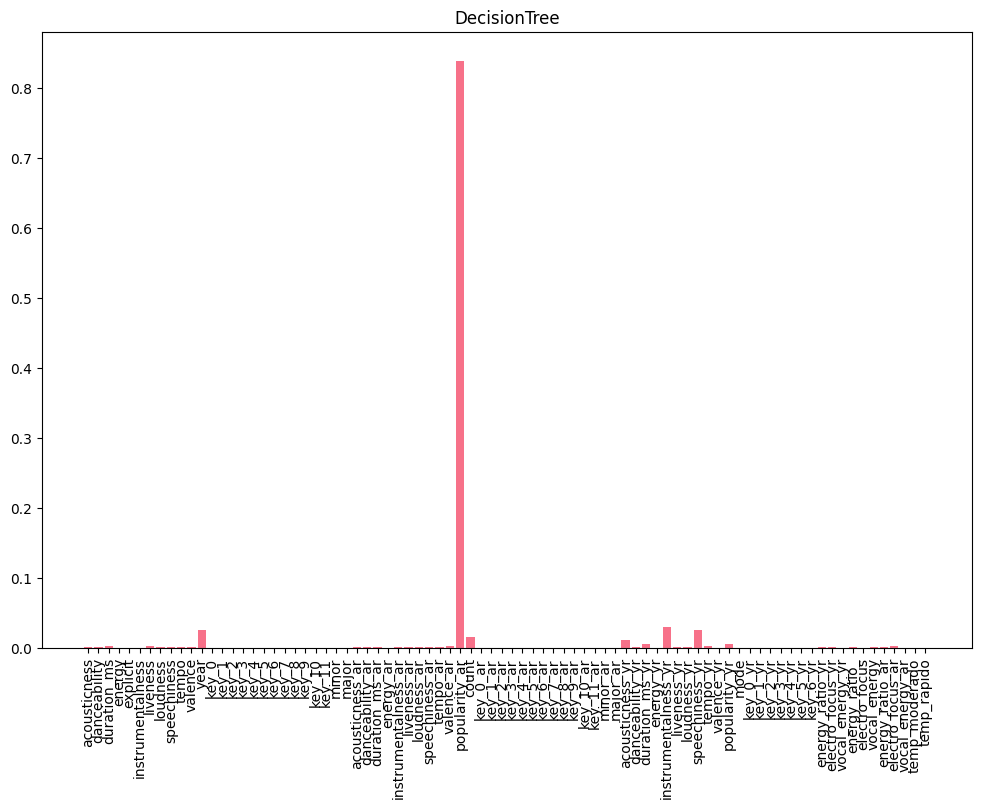

Fitting 5 folds for each of 10 candidates, totalling 50 fits


ValueError: 
All the 50 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/naive_bayes.py", line 762, in fit
    self._count(X, Y)
    ~~~~~~~~~~~^^^^^^
  File "/Library/Frameworks/Python.fra

In [28]:
from sklearn.ensemble import ExtraTreesClassifier,HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
    'MultinomialNB':MultinomialNB()
}
param_grids = {
    'MultinomialNB':{
'alpha':[0.001,0.01,0.1,0.5,1.0],
'fit_prior':[True,False],
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 10]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

In [ ]:
"""from sklearn.utils import class_weight
class_wigths = class_weight.compute_class_weight('balanced',classes=np.unique(y),y=y)

w = dict(zip(np.unique(y),class_wigths))
svc = SVC(kernel='rbf',probability=True,cache_size=1000,decision_function_shape='ovr',class_weight=w,verbose=2)
svc.fit(X_train_reduce,y_train_reduce)
y_pred = svc.predict(X_test_scaled)
r = classification_report(y_test_reduce, y_pred)

print(r)
cm = confusion_matrix(y_test_reduce, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
              yticklabels=['No Popular', 'bajo','media','alta'])
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()"""

# K=30

Fitting 5 folds for each of 9 candidates, totalling 45 fits

RandomForest
Best params: {'max_depth': None, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     14752
           1       0.78      0.82      0.80     12415
           2       0.79      0.72      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.83      0.82      0.83     34446
weighted avg       0.85      0.85      0.85     34446



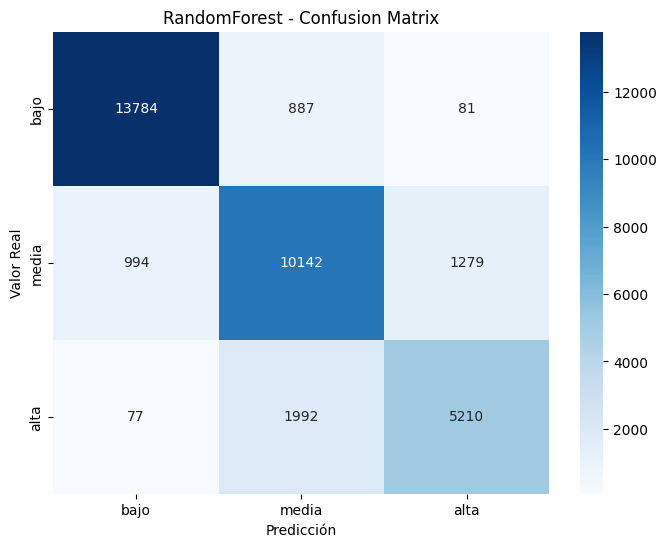


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.34      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



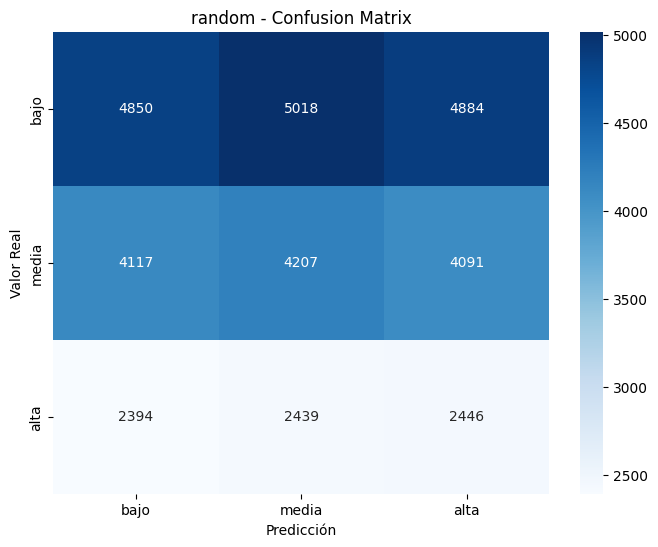

[0.03998252 0.0363425  0.03486352 0.03934614 0.07089052 0.02705322
 0.02363161 0.03081192 0.02678101 0.23362109 0.02861568 0.02462861
 0.00872966 0.00902929 0.04377154 0.01944663 0.00584956 0.04128656
 0.02629459 0.0212632  0.01521139 0.04610064 0.0004022  0.01096523
 0.0289866  0.03692267 0.03808387 0.02907681 0.00088845 0.00112275]


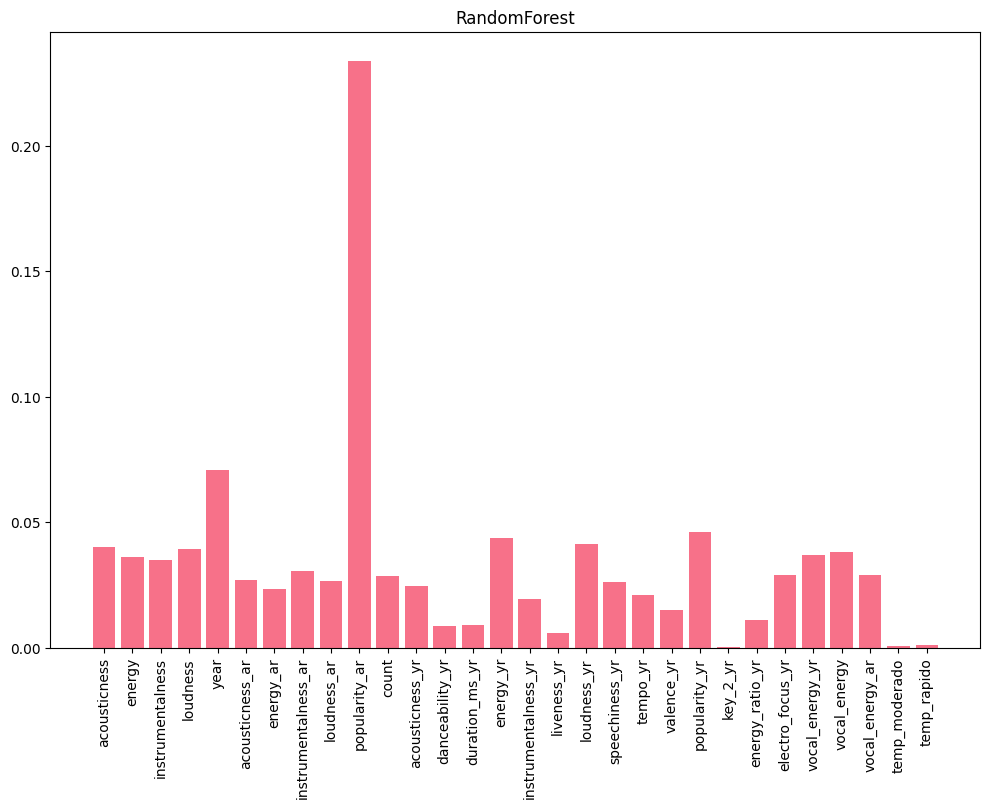

Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 300}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     14752
           1       0.78      0.82      0.80     12415
           2       0.79      0.73      0.76      7279

    accuracy                           0.85     34446
   macro avg       0.84      0.83      0.83     34446
weighted avg       0.85      0.85      0.85     34446



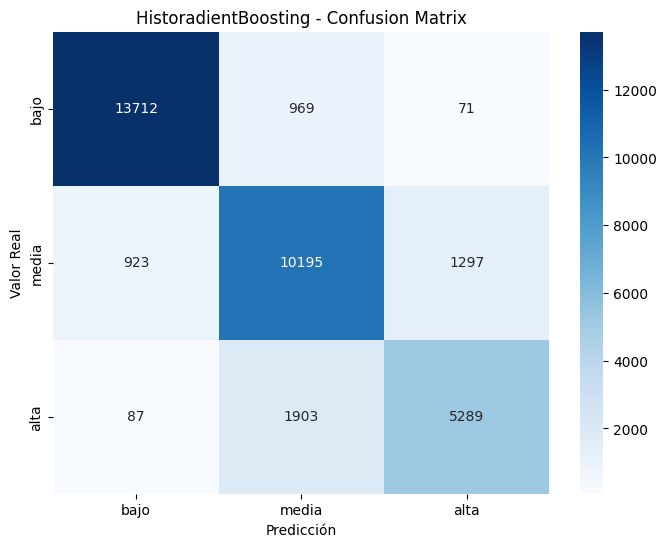


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



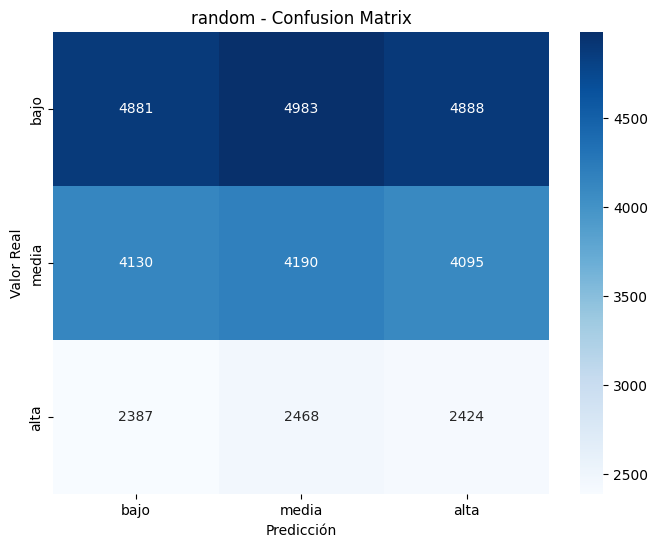

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     14752
           1       0.77      0.81      0.79     12415
           2       0.78      0.72      0.75      7279

    accuracy                           0.84     34446
   macro avg       0.83      0.82      0.82     34446
weighted avg       0.84      0.84      0.84     34446



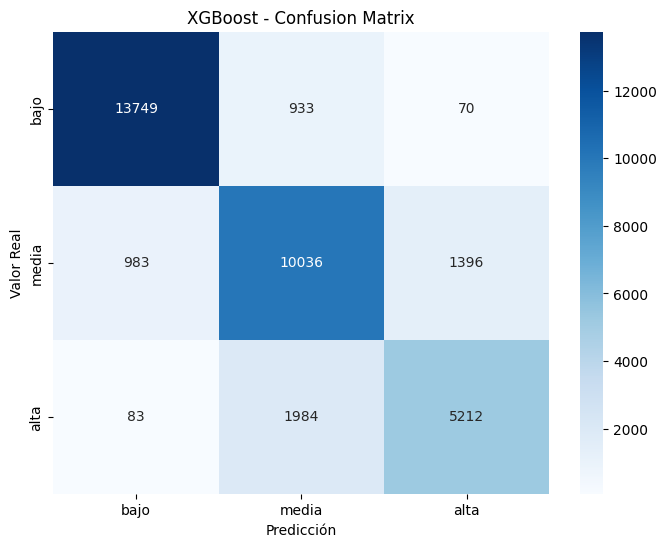


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.33      0.34     12415
           2       0.21      0.34      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.34      0.33     34446
weighted avg       0.36      0.33      0.34     34446



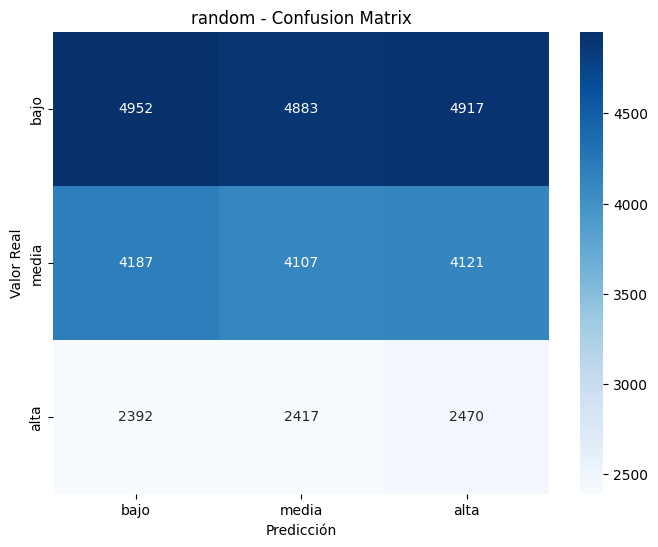

[0.00955937 0.01013196 0.00935798 0.00961354 0.03706576 0.01161561
 0.01137762 0.01169964 0.01113024 0.2940698  0.01675665 0.04547013
 0.0114046  0.01407454 0.01504436 0.02362657 0.00938139 0.01677892
 0.1840208  0.01101633 0.00958968 0.0809914  0.00961968 0.00894394
 0.01023841 0.09473909 0.00814685 0.01055495 0.0039802  0.        ]


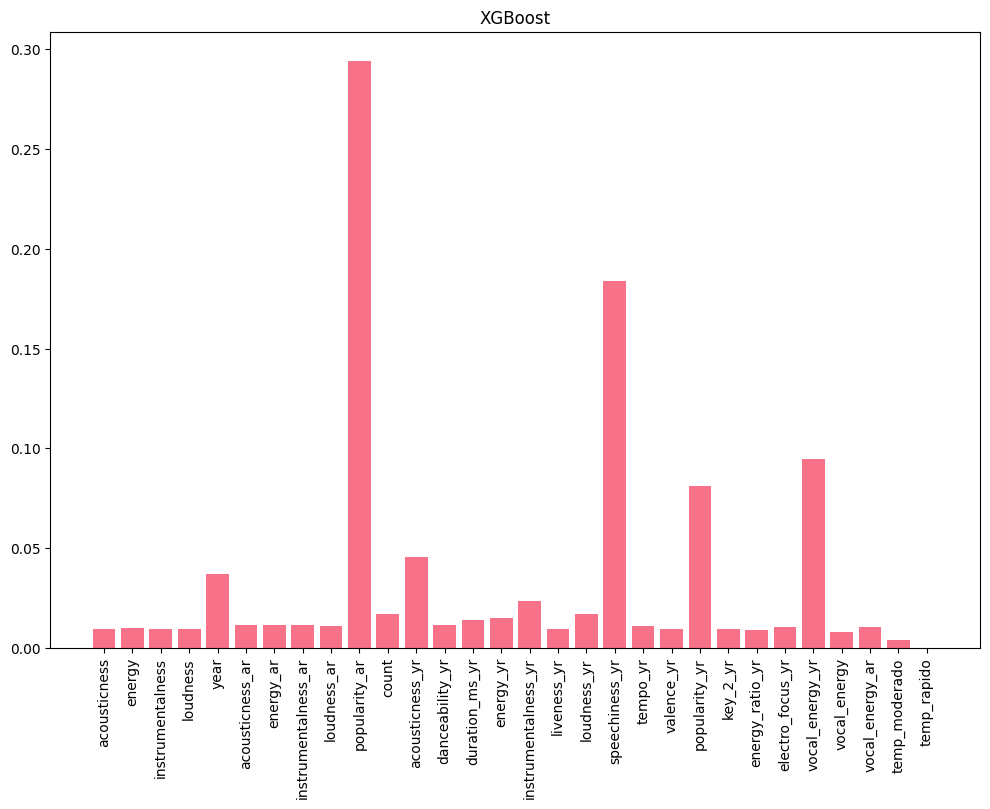

Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': None, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.92      0.93      0.93     14752
           1       0.77      0.80      0.79     12415
           2       0.77      0.70      0.74      7279

    accuracy                           0.84     34446
   macro avg       0.82      0.81      0.82     34446
weighted avg       0.84      0.84      0.84     34446



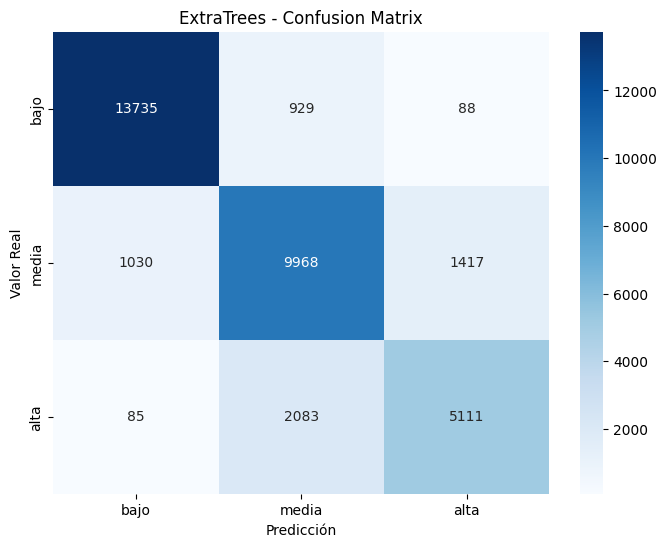


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.33      0.34     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.36      0.33      0.34     34446



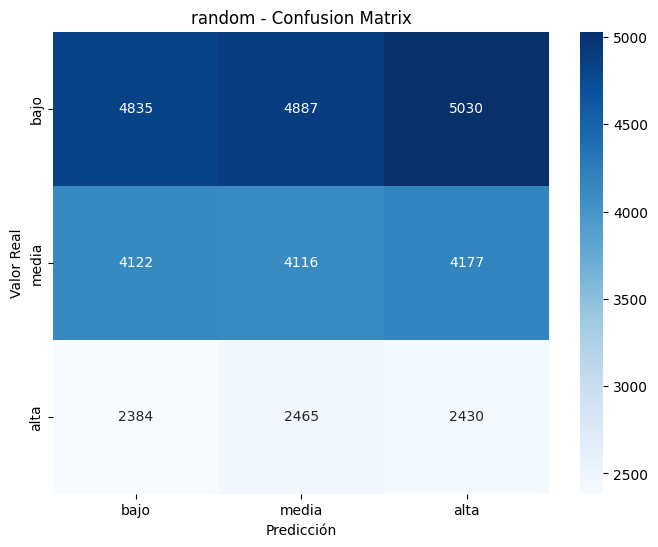

[0.04346399 0.04039341 0.04191899 0.04242181 0.03501066 0.03603265
 0.02867545 0.03690747 0.02849454 0.18731397 0.03316892 0.03687054
 0.01162841 0.00961594 0.04696915 0.02395553 0.00567515 0.04233124
 0.01706665 0.02388394 0.01561604 0.04976847 0.00329649 0.00994197
 0.02187405 0.04100599 0.04192798 0.03303861 0.00630844 0.00542353]


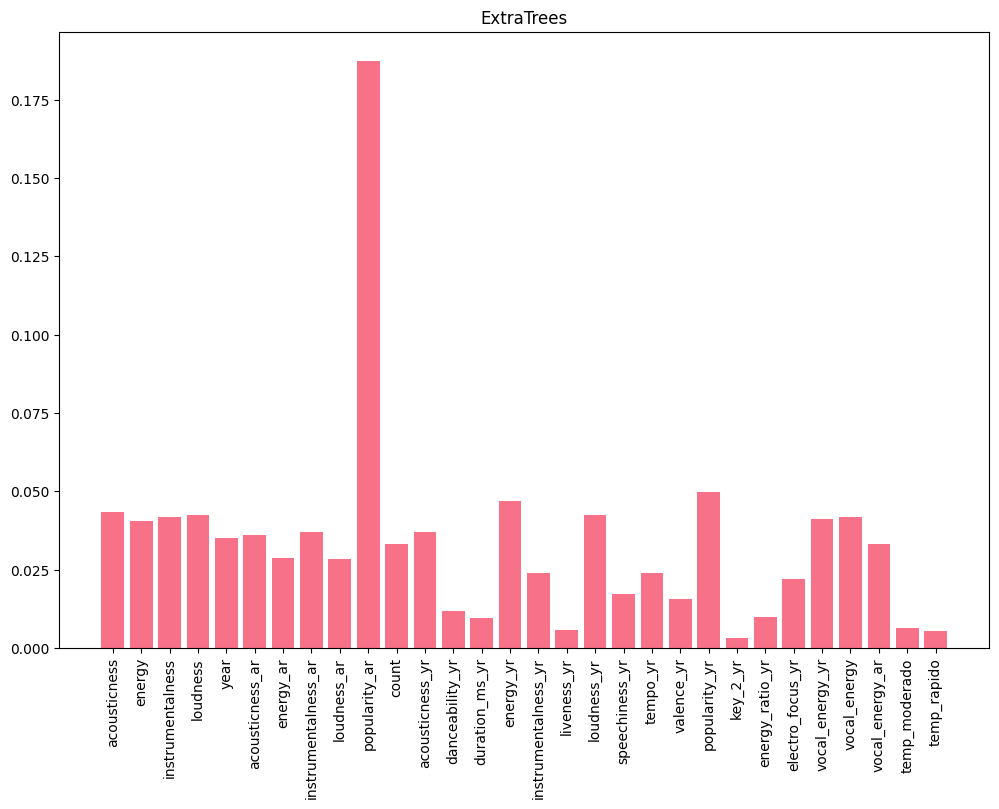

Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     14752
           1       0.78      0.77      0.78     12415
           2       0.75      0.74      0.75      7279

    accuracy                           0.83     34446
   macro avg       0.82      0.81      0.82     34446
weighted avg       0.83      0.83      0.83     34446



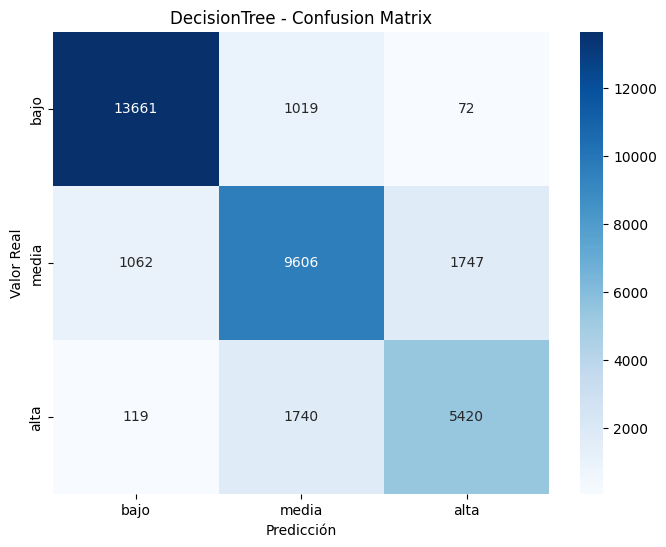


random
              precision    recall  f1-score   support

           0       0.42      0.34      0.37     14752
           1       0.36      0.33      0.34     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.35      0.33      0.34     34446



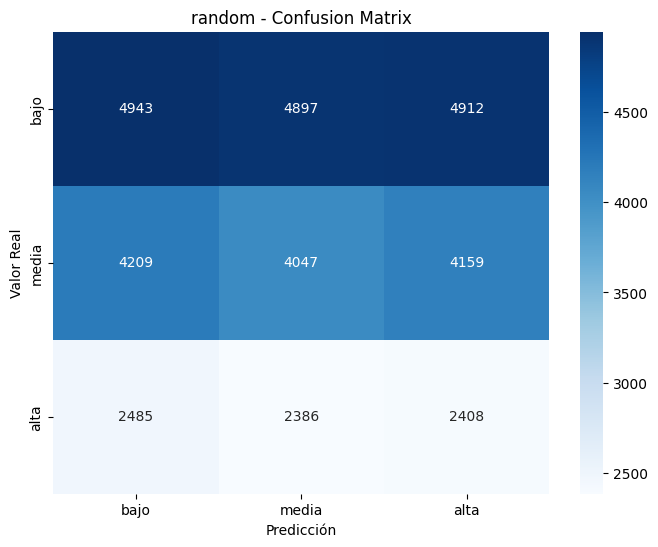

[1.92303982e-03 2.22447435e-03 1.61916689e-03 2.74433949e-03
 1.50118063e-02 2.67211225e-03 2.44352673e-03 4.92338971e-03
 3.47720367e-03 8.41797292e-01 1.79192684e-02 1.45366975e-03
 7.78727467e-04 2.70934512e-03 6.65941018e-03 1.60541237e-03
 1.21920317e-03 1.95285643e-02 2.72310341e-02 4.28391434e-04
 4.07746303e-04 3.38009032e-02 0.00000000e+00 1.33776852e-03
 1.06420863e-03 1.40901255e-03 1.11259548e-03 2.47073359e-03
 2.76539972e-05 0.00000000e+00]


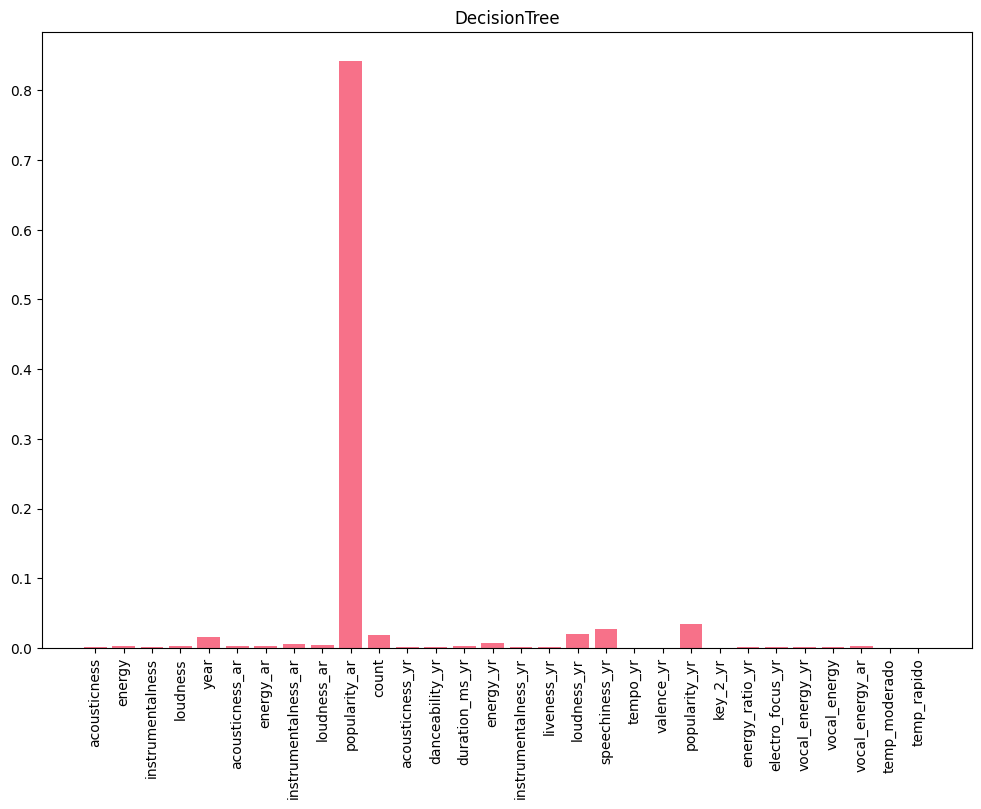

In [29]:
selector = SelectKBest(score_func=f_classif,k=30)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
smote = SMOTE(sampling_strategy='auto')
X_train_reduce,y_train_reduce = smote.fit_resample(X_train_reduce,y_train_reduce)
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
    
}
param_grids = {
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

# k=20


Fitting 5 folds for each of 9 candidates, totalling 45 fits

RandomForest
Best params: {'max_depth': None, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.92      0.93      0.93     14752
           1       0.77      0.80      0.78     12415
           2       0.76      0.71      0.74      7279

    accuracy                           0.84     34446
   macro avg       0.82      0.81      0.82     34446
weighted avg       0.84      0.84      0.84     34446



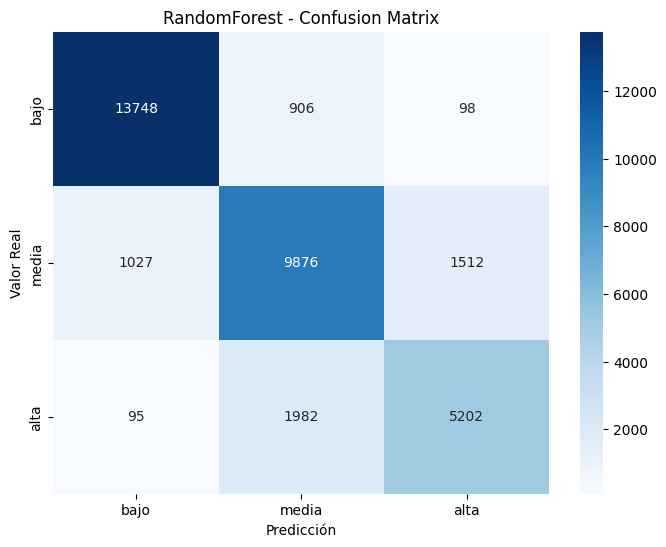


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.33      0.25      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



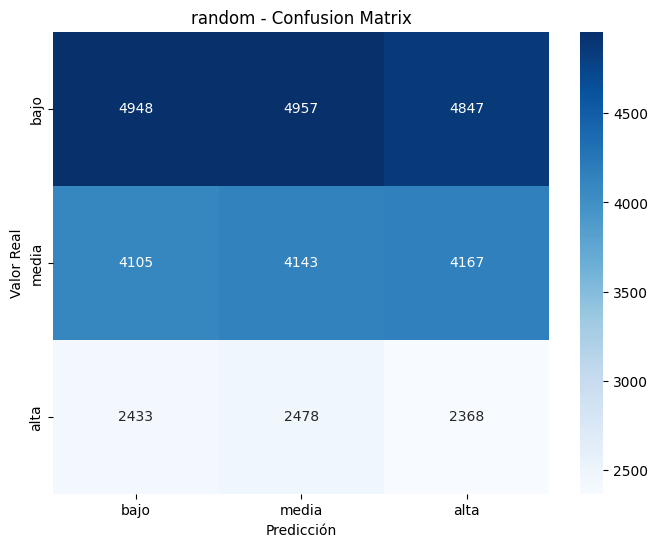

[0.07822418 0.07346668 0.03409443 0.03072801 0.03897093 0.03480533
 0.26734422 0.03405543 0.00712058 0.04906546 0.01816746 0.04112095
 0.02694825 0.0266067  0.01381512 0.05064743 0.01971087 0.03887701
 0.08124616 0.0349848 ]


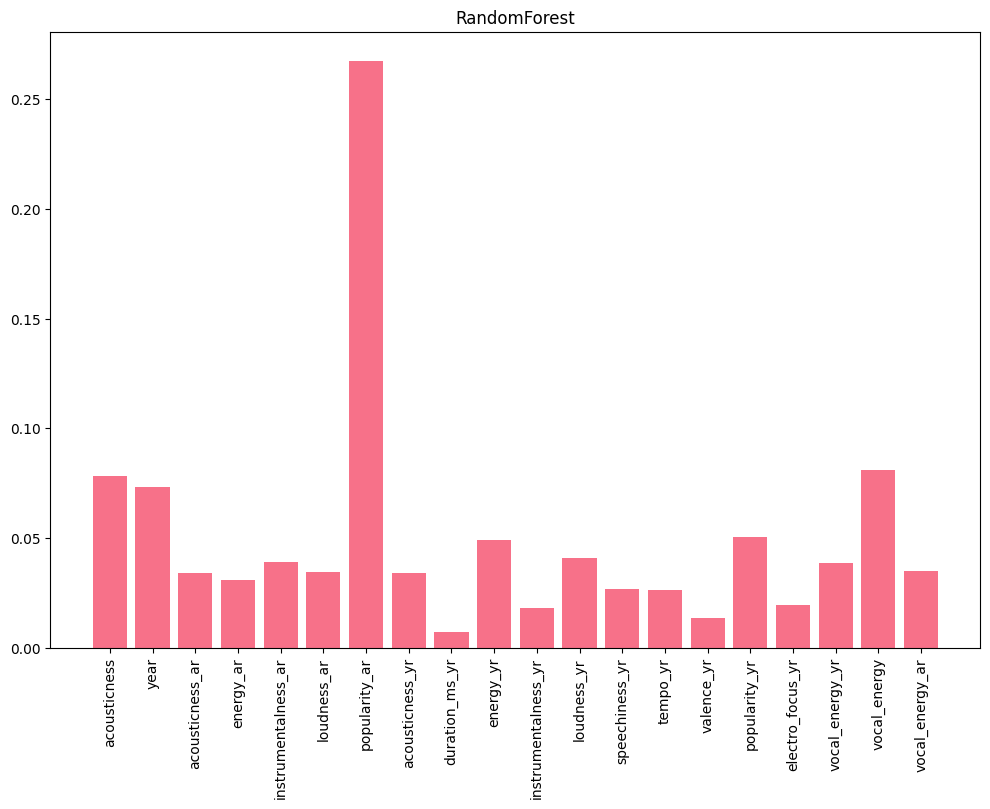

Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 300}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     14752
           1       0.78      0.81      0.80     12415
           2       0.79      0.72      0.76      7279

    accuracy                           0.85     34446
   macro avg       0.83      0.82      0.83     34446
weighted avg       0.85      0.85      0.85     34446



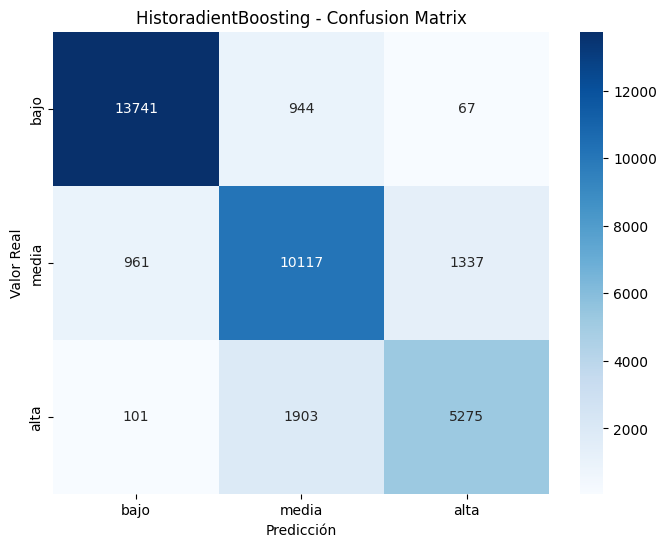


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



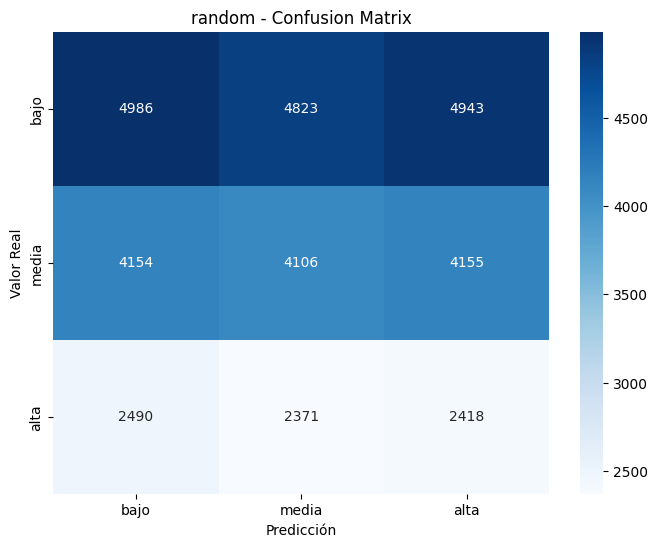

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.92      0.93      0.93     14752
           1       0.77      0.79      0.78     12415
           2       0.76      0.71      0.74      7279

    accuracy                           0.83     34446
   macro avg       0.82      0.81      0.81     34446
weighted avg       0.83      0.83      0.83     34446



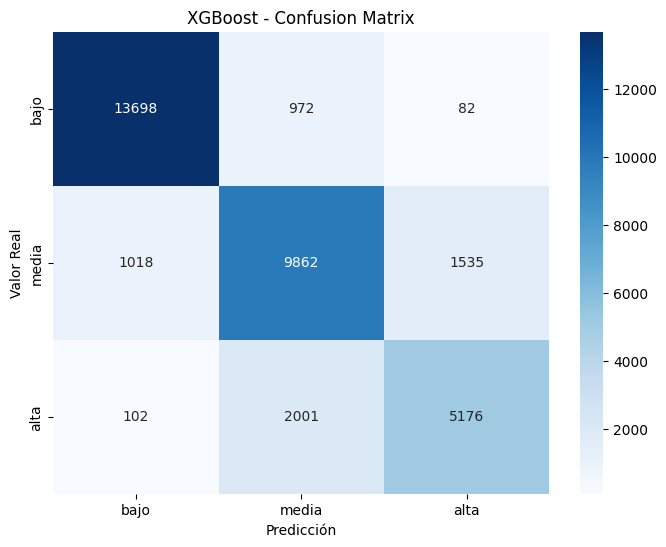


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.34     34446
   macro avg       0.34      0.34      0.33     34446
weighted avg       0.36      0.34      0.34     34446



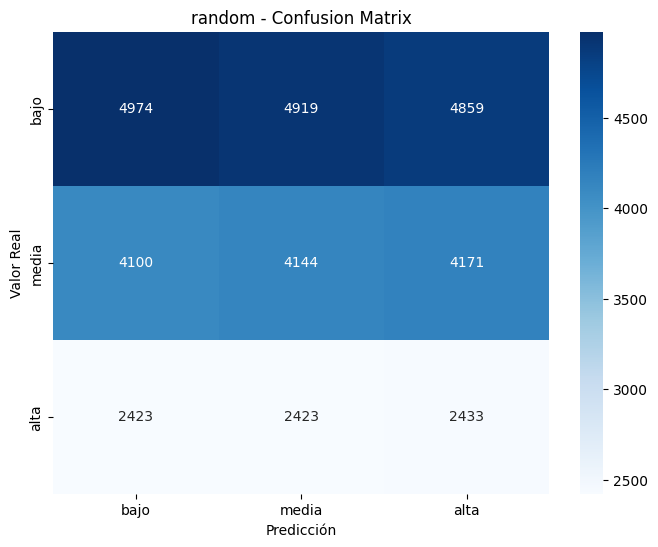

[0.01282677 0.04778906 0.01761418 0.01726541 0.01896189 0.01682218
 0.32276797 0.03698476 0.02377477 0.03789704 0.04760493 0.02337434
 0.18273005 0.01568032 0.01358345 0.05874294 0.01390266 0.06296805
 0.01282767 0.0158817 ]


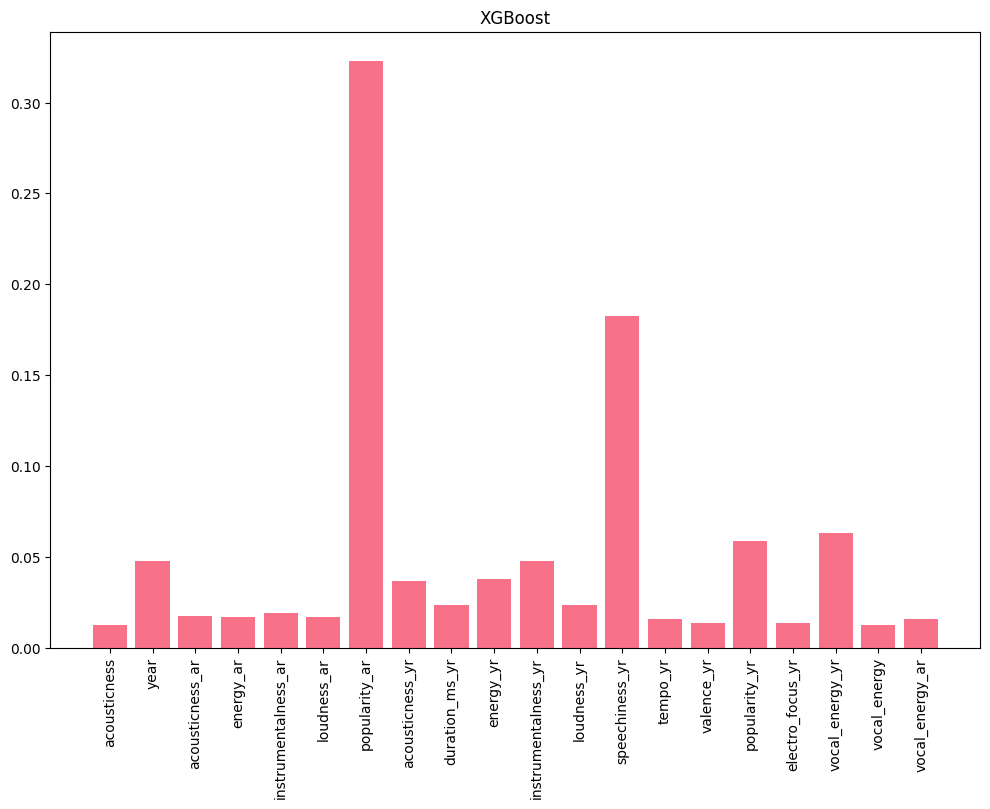

Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': None, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     14752
           1       0.76      0.78      0.77     12415
           2       0.74      0.71      0.72      7279

    accuracy                           0.83     34446
   macro avg       0.81      0.80      0.81     34446
weighted avg       0.83      0.83      0.83     34446



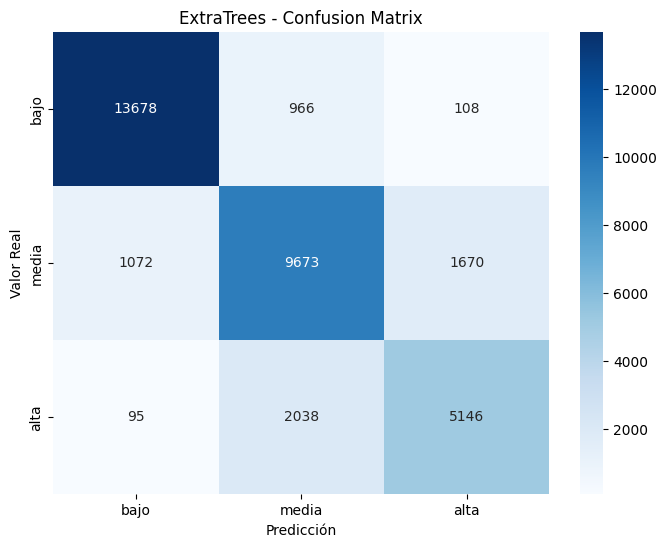


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.34      0.26      7279

    accuracy                           0.34     34446
   macro avg       0.34      0.34      0.33     34446
weighted avg       0.36      0.34      0.34     34446



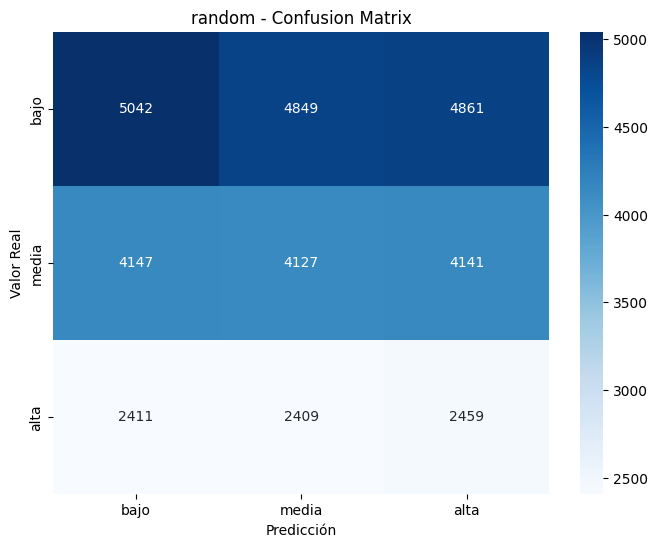

[0.08779336 0.04807091 0.04263742 0.03759459 0.04735441 0.03812206
 0.20764498 0.03829414 0.01048995 0.04795899 0.02548693 0.04548859
 0.01888631 0.03155932 0.01848889 0.05280299 0.02313928 0.0454146
 0.08879475 0.04397752]


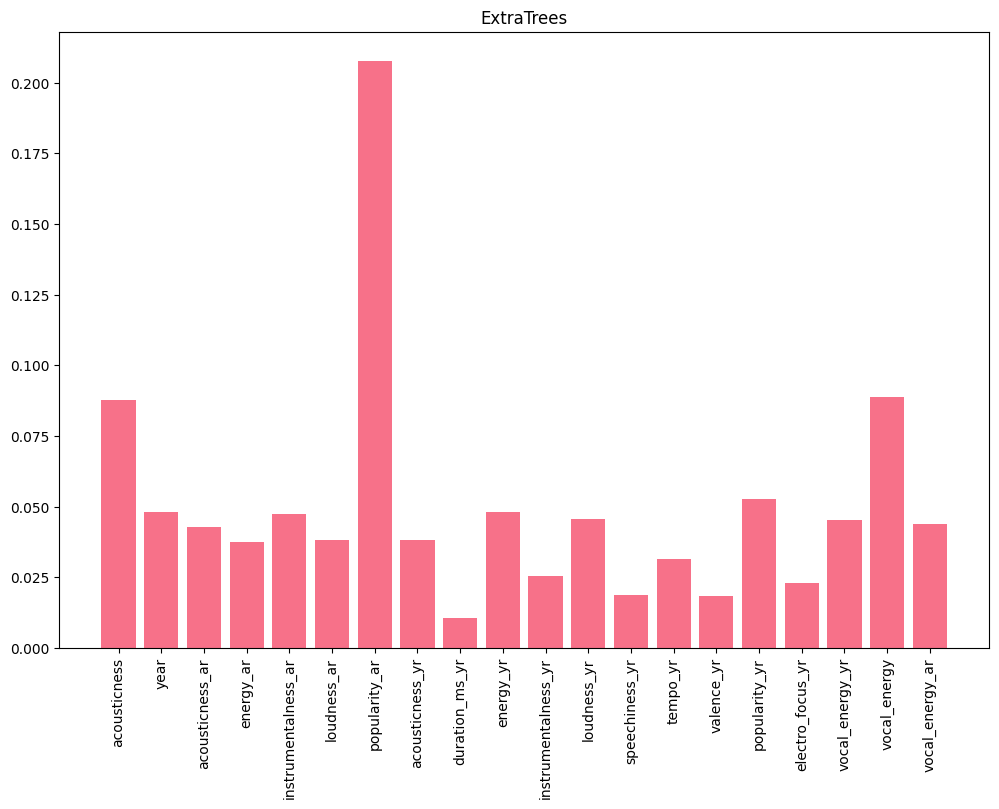

Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     14752
           1       0.78      0.79      0.78     12415
           2       0.77      0.73      0.75      7279

    accuracy                           0.84     34446
   macro avg       0.82      0.82      0.82     34446
weighted avg       0.84      0.84      0.84     34446



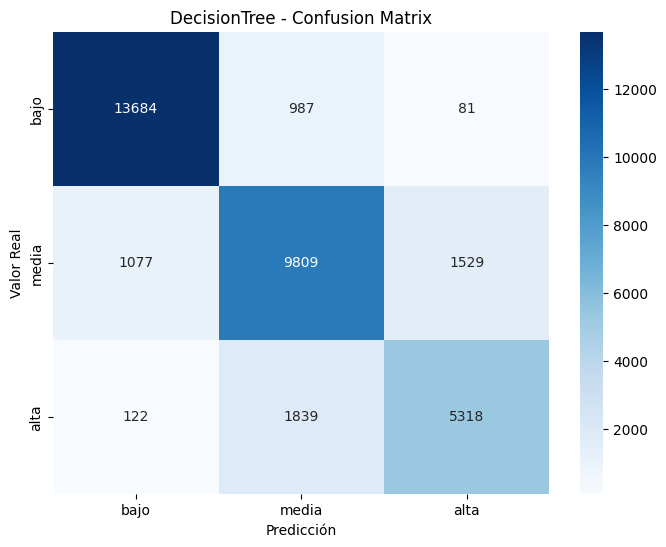


random
              precision    recall  f1-score   support

           0       0.42      0.33      0.37     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.36      0.33      0.34     34446



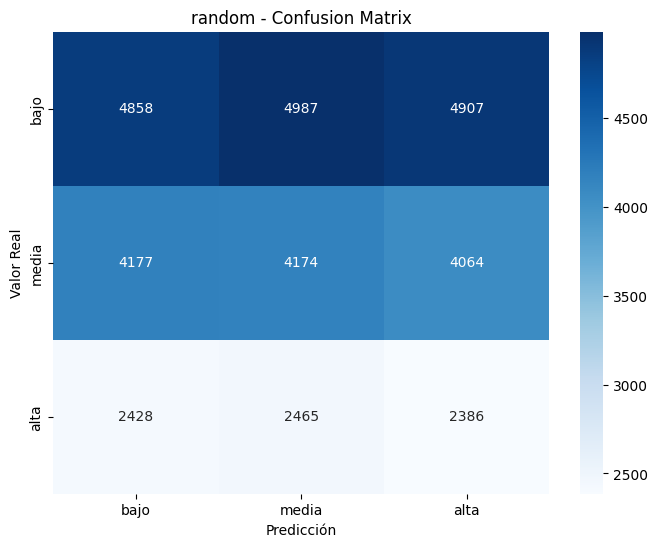

[3.84966978e-03 1.85757332e-02 3.75845230e-03 3.24203296e-03
 8.70054187e-03 4.70738347e-03 8.47130915e-01 3.51287065e-03
 1.66988452e-03 7.53214224e-03 4.36096515e-03 1.87269597e-02
 2.57961052e-02 1.31062128e-03 1.72494342e-03 3.36145455e-02
 2.31983477e-03 5.53404374e-04 5.06221482e-03 3.85077940e-03]


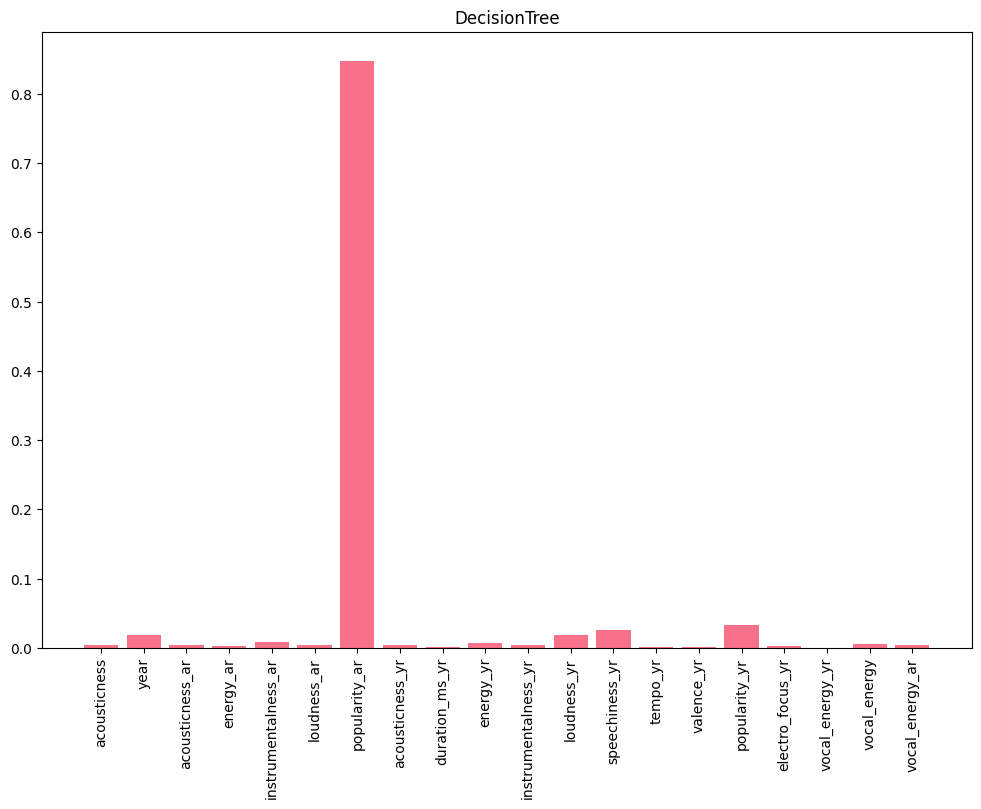

In [30]:
selector = SelectKBest(score_func=f_classif,k=20)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
smote = SMOTE(sampling_strategy='auto')
X_train_reduce,y_train_reduce = smote.fit_resample(X_train_reduce,y_train_reduce)
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
     
}
param_grids = {
   
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

# k=10


Fitting 5 folds for each of 9 candidates, totalling 45 fits

RandomForest
Best params: {'max_depth': None, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     14752
           1       0.77      0.79      0.78     12415
           2       0.76      0.71      0.73      7279

    accuracy                           0.83     34446
   macro avg       0.82      0.81      0.81     34446
weighted avg       0.83      0.83      0.83     34446



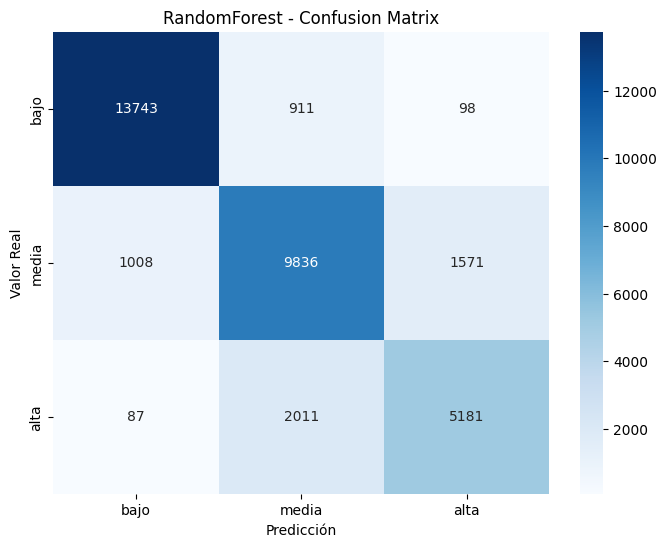


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.33      0.34     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.36      0.33      0.34     34446



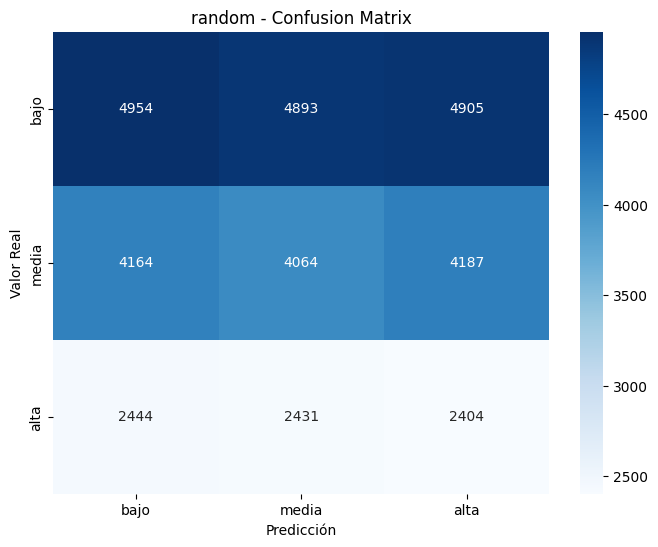

[0.11245385 0.45661137 0.02644665 0.04726904 0.01858523 0.05027867
 0.02206529 0.07842542 0.05392447 0.13394   ]


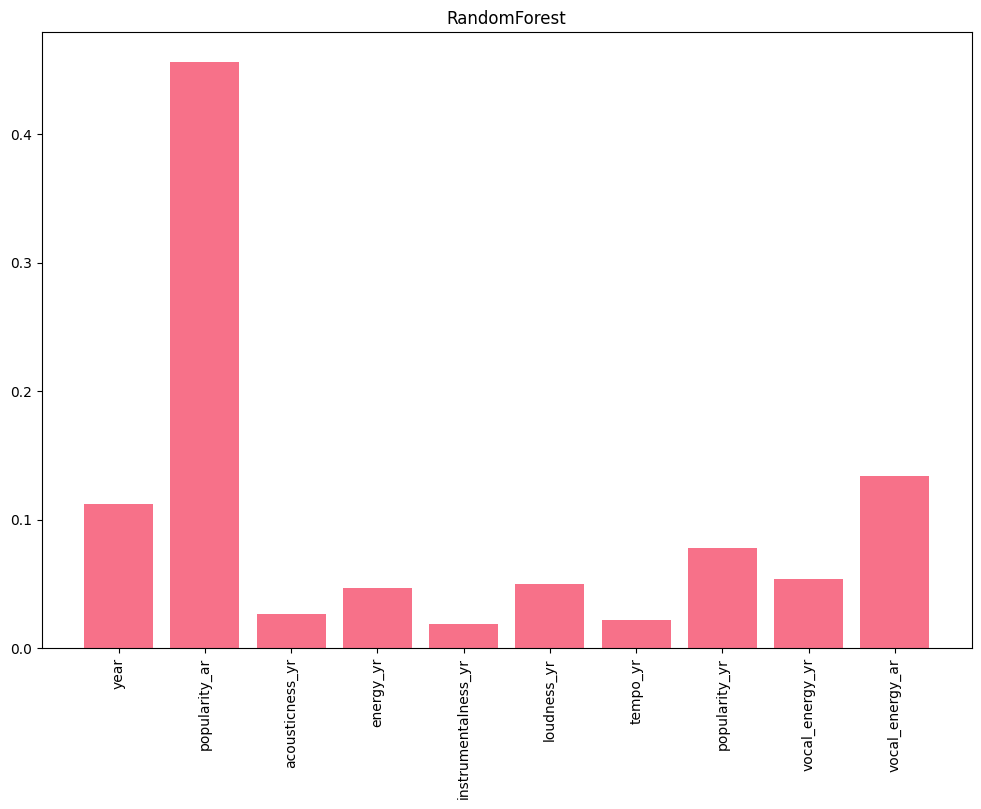

Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 300}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     14752
           1       0.77      0.81      0.79     12415
           2       0.78      0.72      0.75      7279

    accuracy                           0.84     34446
   macro avg       0.83      0.82      0.82     34446
weighted avg       0.84      0.84      0.84     34446



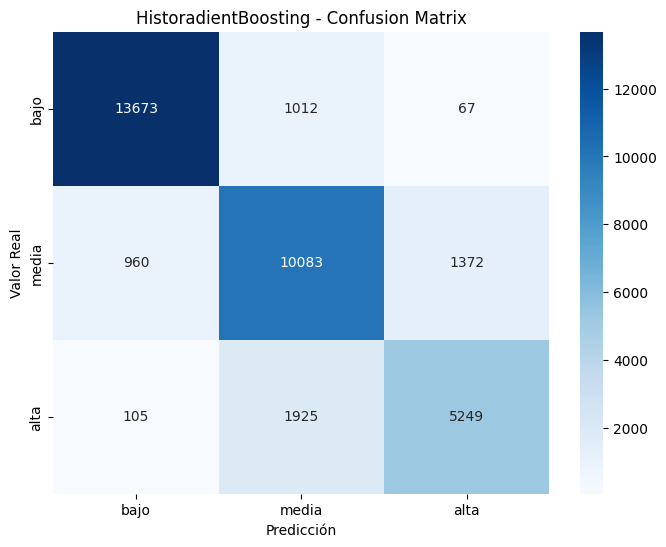


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.33      0.34     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.36      0.33      0.34     34446



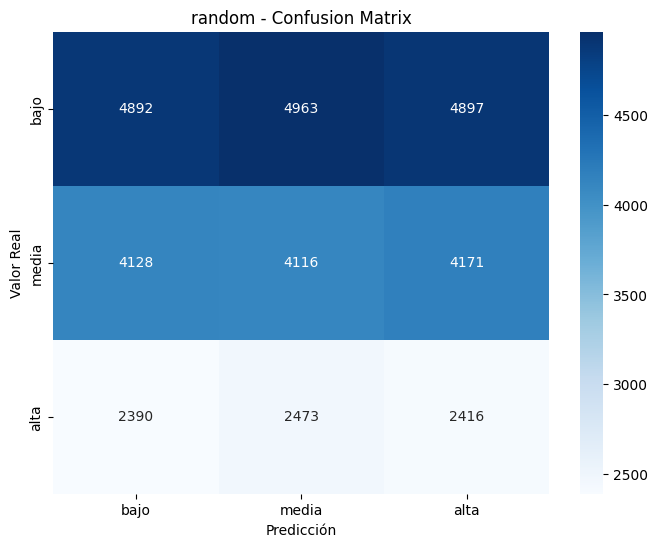

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     14752
           1       0.77      0.79      0.78     12415
           2       0.75      0.71      0.73      7279

    accuracy                           0.83     34446
   macro avg       0.81      0.81      0.81     34446
weighted avg       0.83      0.83      0.83     34446



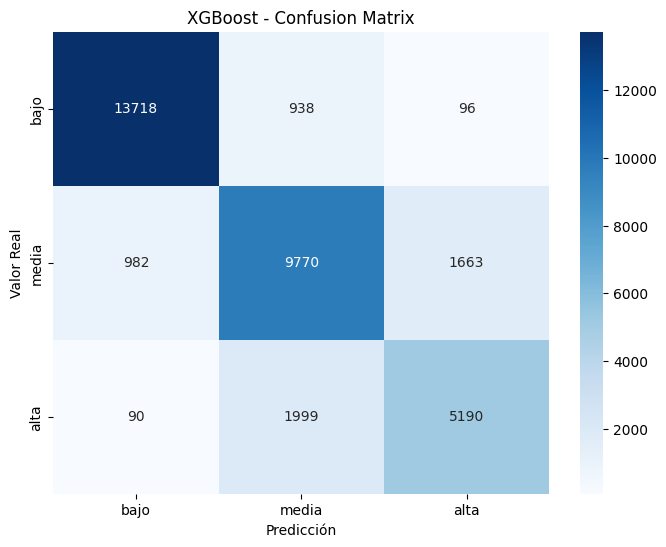


random
              precision    recall  f1-score   support

           0       0.44      0.34      0.38     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.34      0.26      7279

    accuracy                           0.34     34446
   macro avg       0.34      0.34      0.33     34446
weighted avg       0.36      0.34      0.34     34446



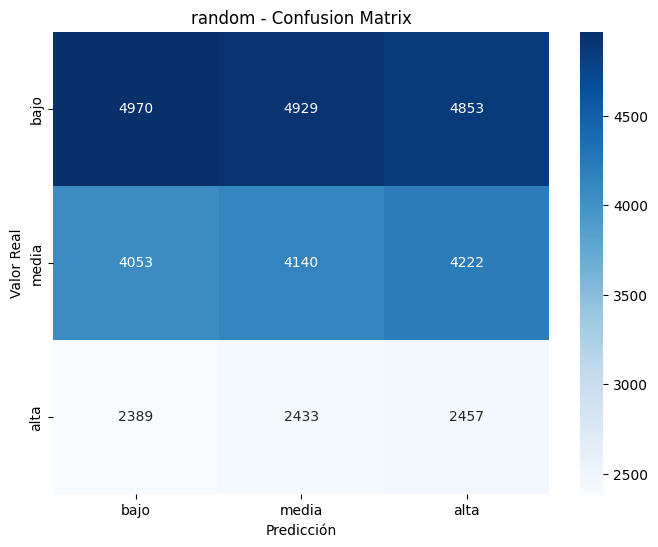

[0.04956723 0.2710654  0.03522461 0.07182721 0.21046728 0.06966314
 0.03285086 0.07162401 0.15639782 0.03131244]


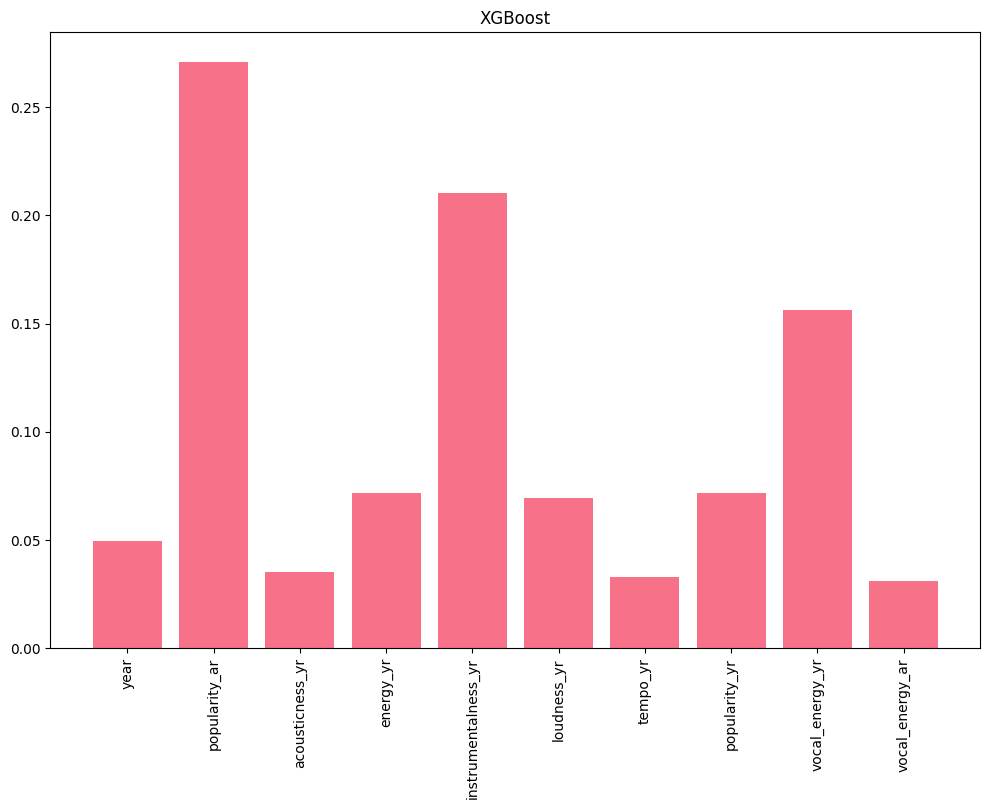

Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': None, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     14752
           1       0.77      0.80      0.78     12415
           2       0.77      0.69      0.73      7279

    accuracy                           0.83     34446
   macro avg       0.82      0.81      0.81     34446
weighted avg       0.83      0.83      0.83     34446



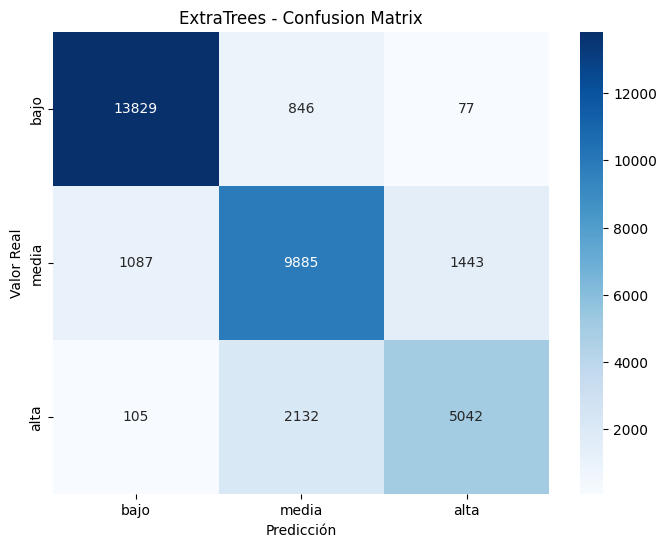


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.34      0.26      7279

    accuracy                           0.34     34446
   macro avg       0.34      0.34      0.33     34446
weighted avg       0.36      0.34      0.34     34446



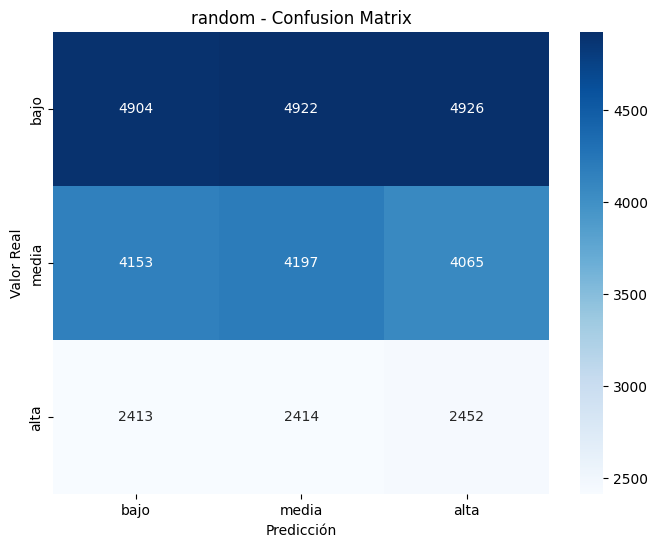

[0.06951432 0.39638896 0.06322228 0.07352352 0.03151622 0.0628461
 0.03194003 0.07462884 0.05812795 0.13829178]


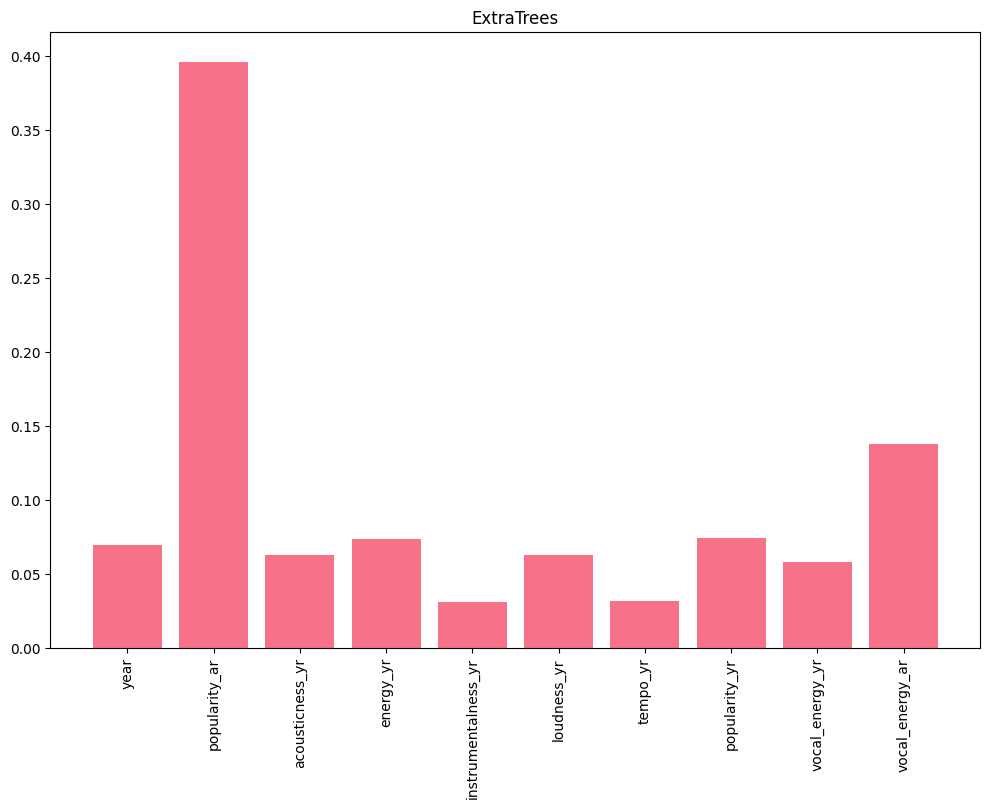

Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': None}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     14752
           1       0.76      0.79      0.78     12415
           2       0.76      0.68      0.72      7279

    accuracy                           0.83     34446
   macro avg       0.81      0.80      0.81     34446
weighted avg       0.83      0.83      0.83     34446



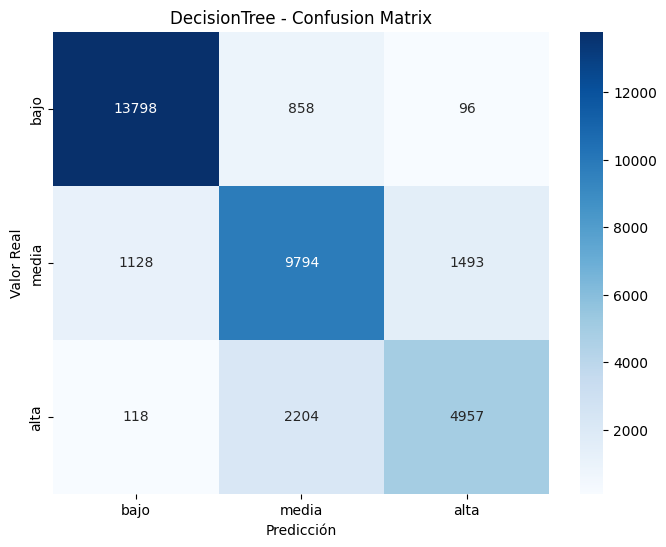


random
              precision    recall  f1-score   support

           0       0.42      0.33      0.37     14752
           1       0.36      0.33      0.34     12415
           2       0.21      0.32      0.25      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.35      0.33      0.33     34446



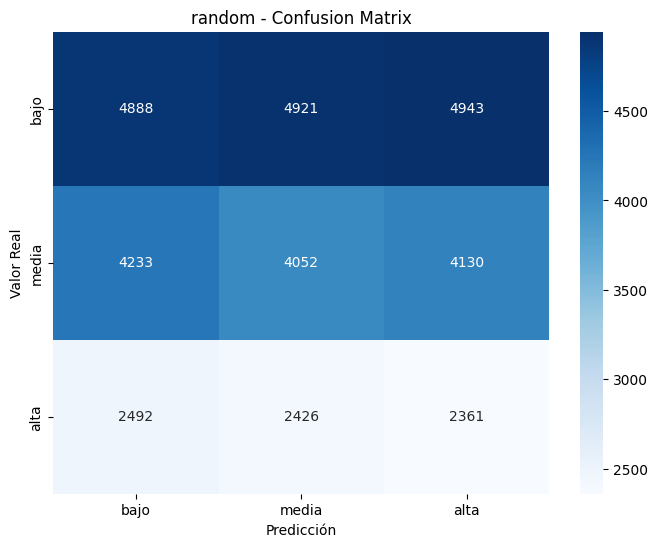

[0.02152227 0.76135991 0.01206659 0.00746807 0.0205384  0.02462116
 0.00881727 0.03589613 0.00768795 0.10002224]


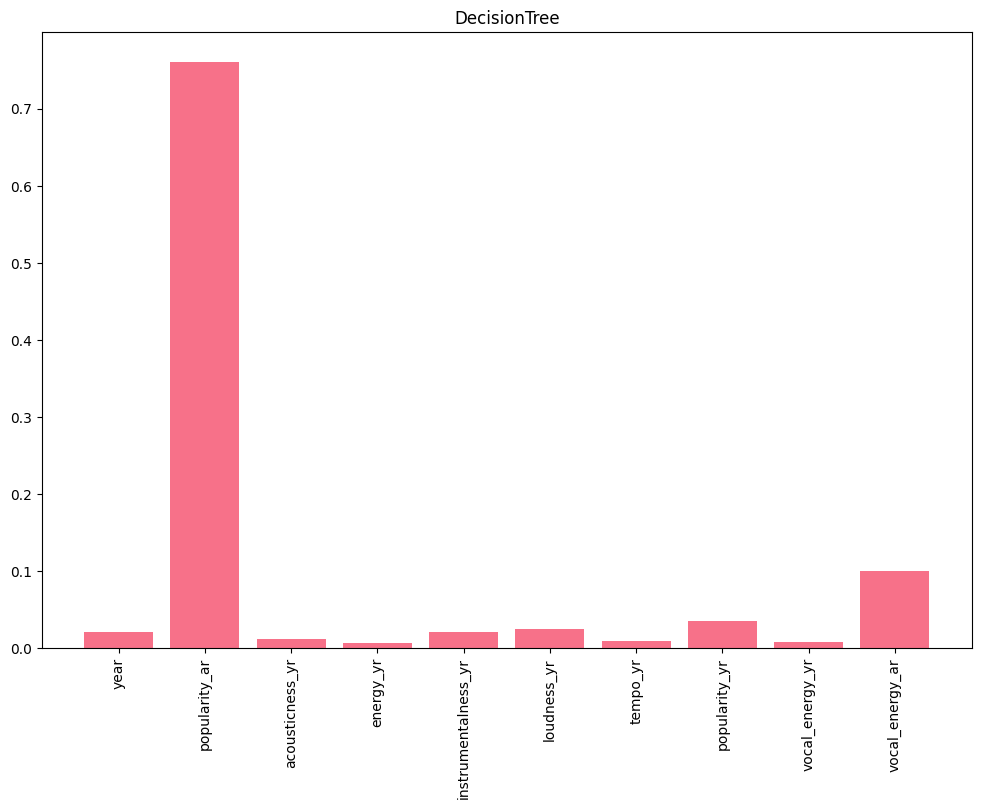

In [31]:
selector = SelectKBest(score_func=f_classif,k=10)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
smote = SMOTE(sampling_strategy='auto')
X_train_reduce,y_train_reduce = smote.fit_resample(X_train_reduce,y_train_reduce)
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
   
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

# PCA n=2

Fitting 5 folds for each of 9 candidates, totalling 45 fits

RandomForest
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.70      0.67      0.68     14752
           1       0.52      0.48      0.50     12415
           2       0.39      0.48      0.43      7279

    accuracy                           0.56     34446
   macro avg       0.54      0.54      0.54     34446
weighted avg       0.57      0.56      0.56     34446



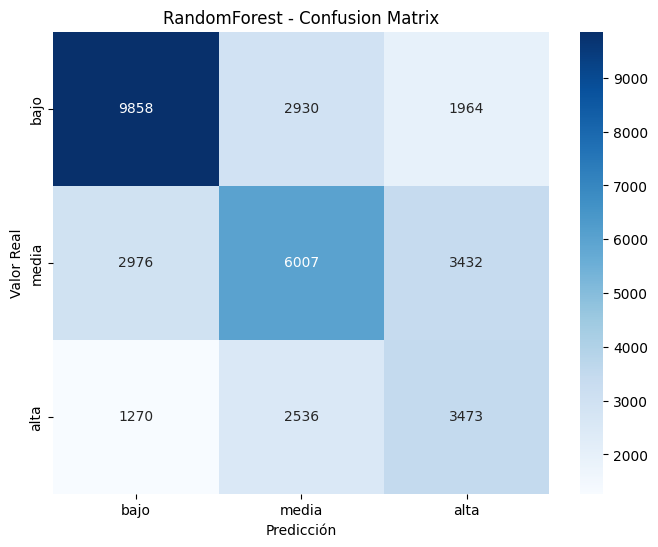


random
              precision    recall  f1-score   support

           0       0.42      0.33      0.37     14752
           1       0.35      0.32      0.34     12415
           2       0.21      0.33      0.25      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.35      0.33      0.33     34446



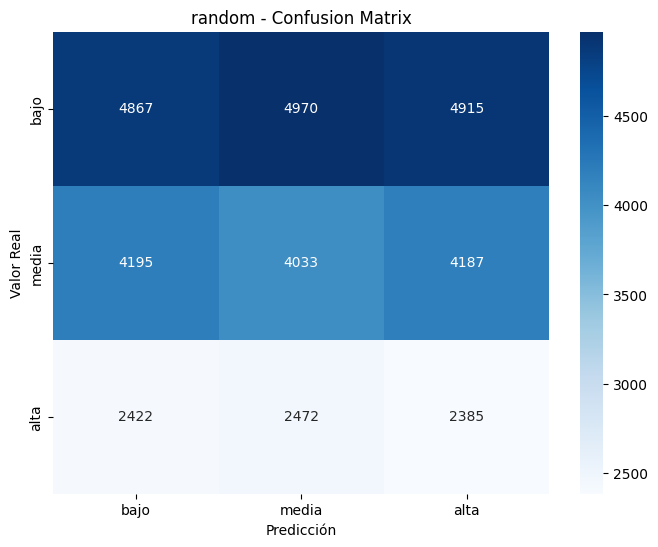

[0.51732385 0.48267615]
error shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (82,) and arg 1 with shape (2,).
Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 200}
              precision    recall  f1-score   support

           0       0.70      0.68      0.69     14752
           1       0.54      0.50      0.52     12415
           2       0.42      0.49      0.45      7279

    accuracy                           0.58     34446
   macro avg       0.55      0.56      0.55     34446
weighted avg       0.58      0.58      0.58     34446



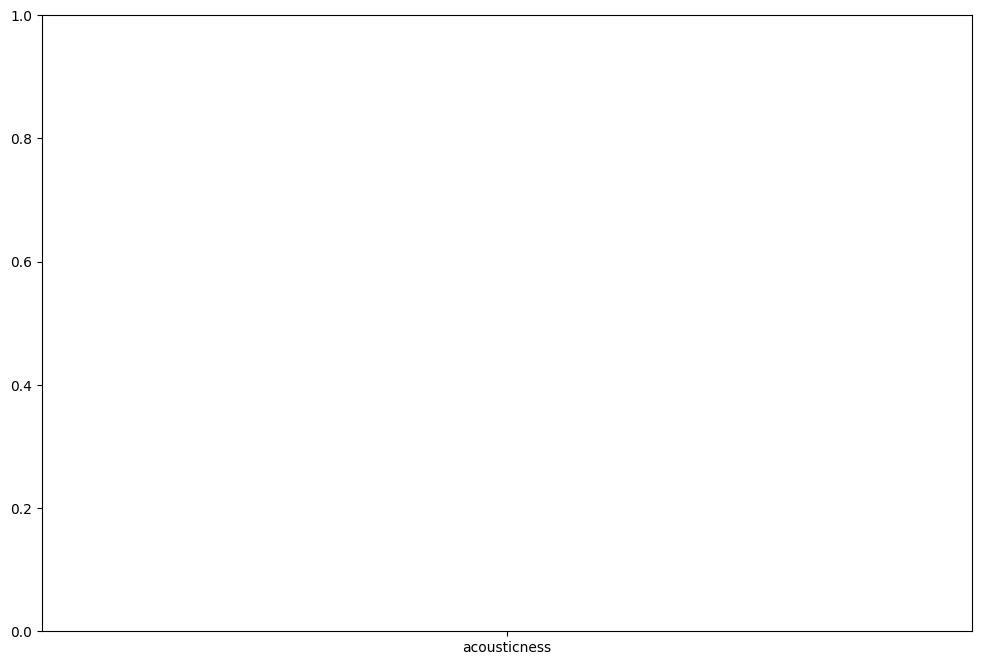

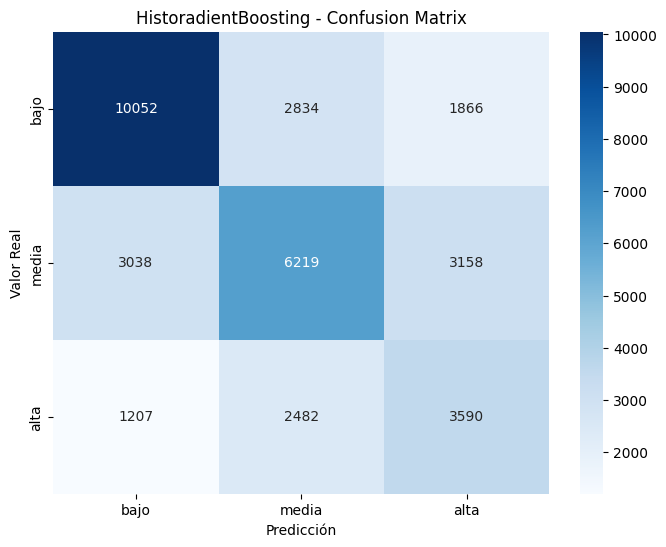


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.34      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



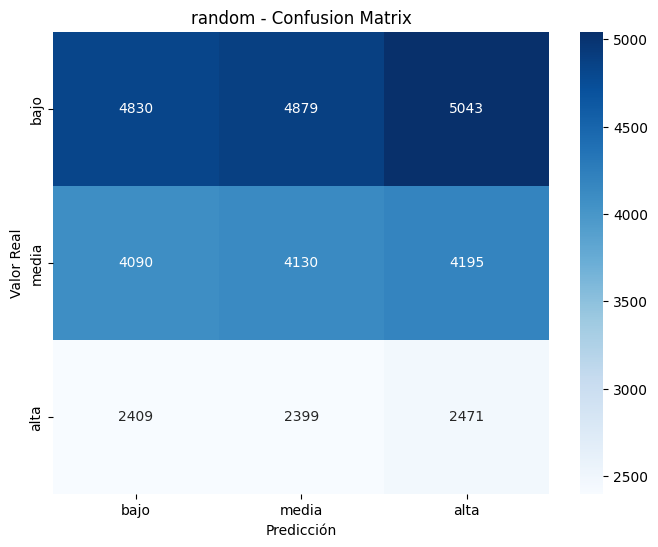

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.70      0.67      0.68     14752
           1       0.52      0.47      0.49     12415
           2       0.39      0.49      0.43      7279

    accuracy                           0.56     34446
   macro avg       0.54      0.54      0.54     34446
weighted avg       0.57      0.56      0.56     34446



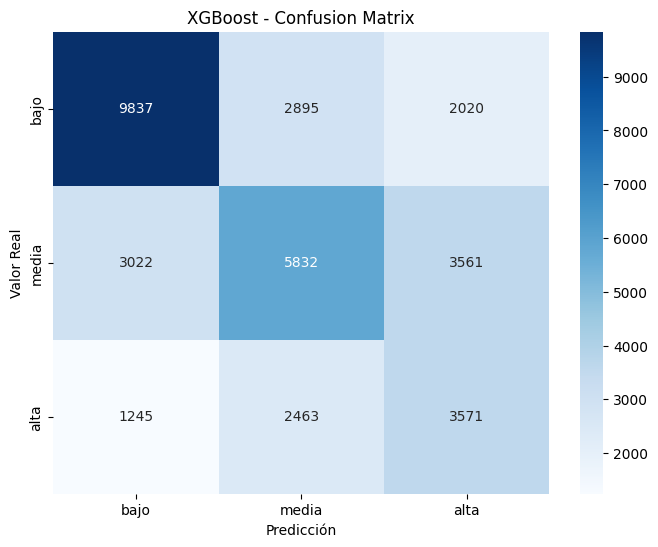


random
              precision    recall  f1-score   support

           0       0.42      0.33      0.37     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



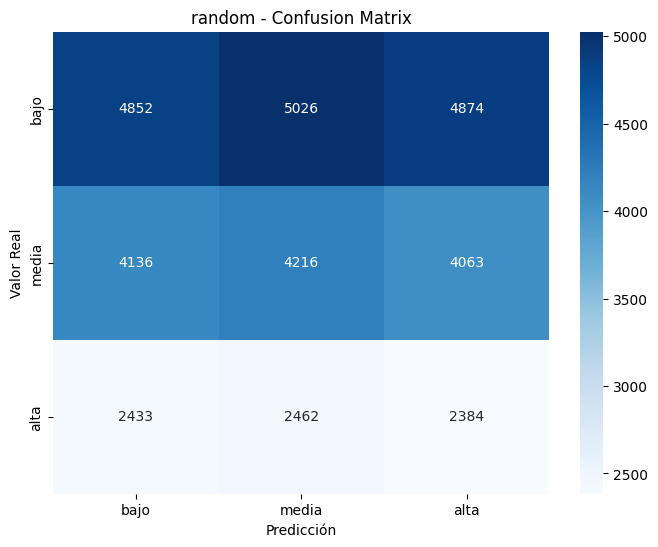

[0.50669146 0.4933085 ]
error shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (82,) and arg 1 with shape (2,).
Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': None, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.67      0.63      0.65     14752
           1       0.49      0.46      0.47     12415
           2       0.35      0.42      0.38      7279

    accuracy                           0.53     34446
   macro avg       0.50      0.50      0.50     34446
weighted avg       0.53      0.53      0.53     34446



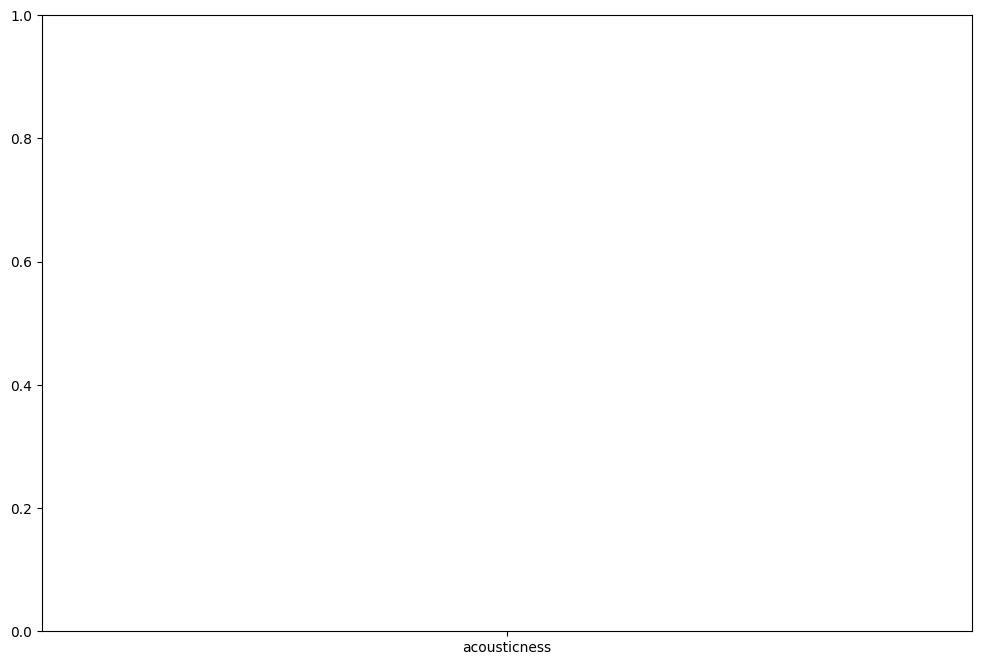

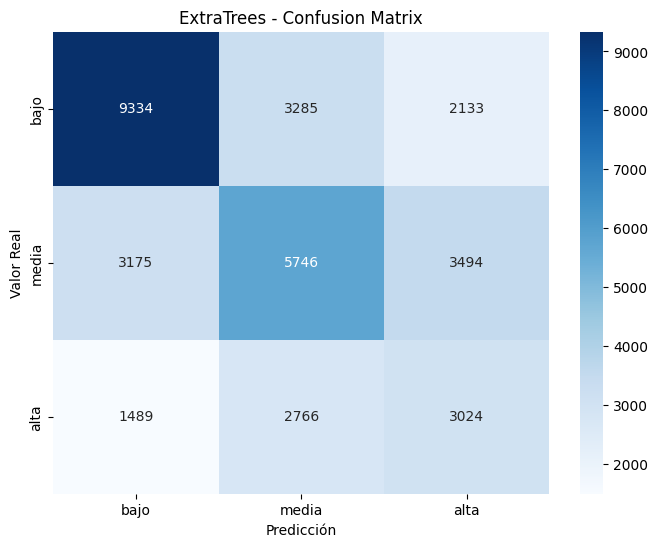


random
              precision    recall  f1-score   support

           0       0.42      0.33      0.37     14752
           1       0.35      0.33      0.34     12415
           2       0.21      0.32      0.25      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.35      0.33      0.33     34446



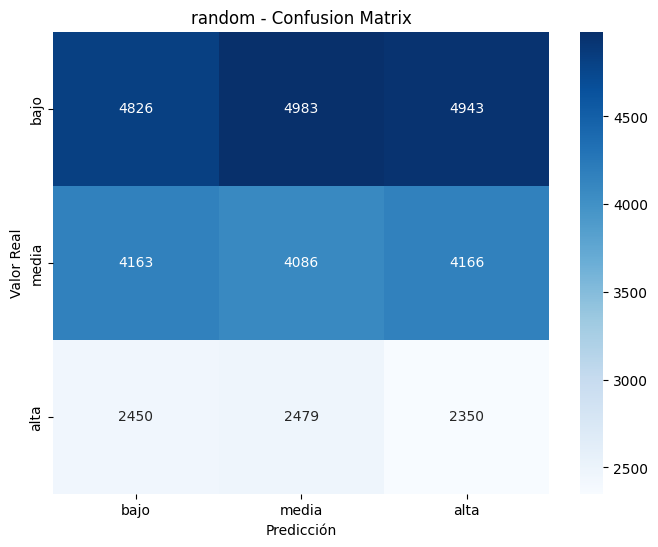

[0.50028012 0.49971988]
error shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (82,) and arg 1 with shape (2,).
Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.71      0.66      0.68     14752
           1       0.54      0.53      0.53     12415
           2       0.41      0.48      0.44      7279

    accuracy                           0.57     34446
   macro avg       0.55      0.56      0.55     34446
weighted avg       0.58      0.57      0.58     34446



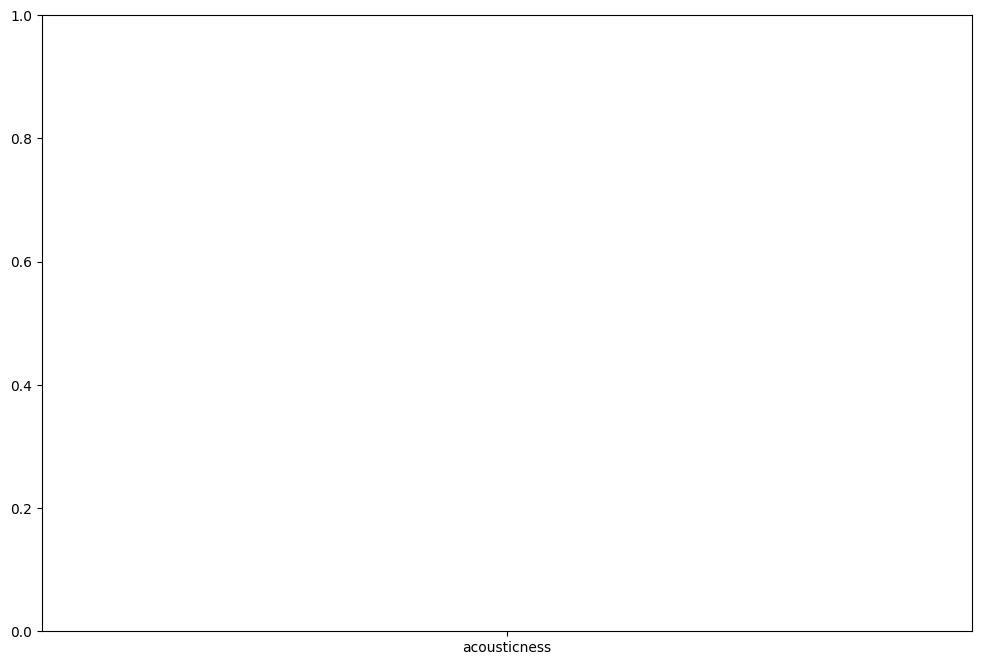

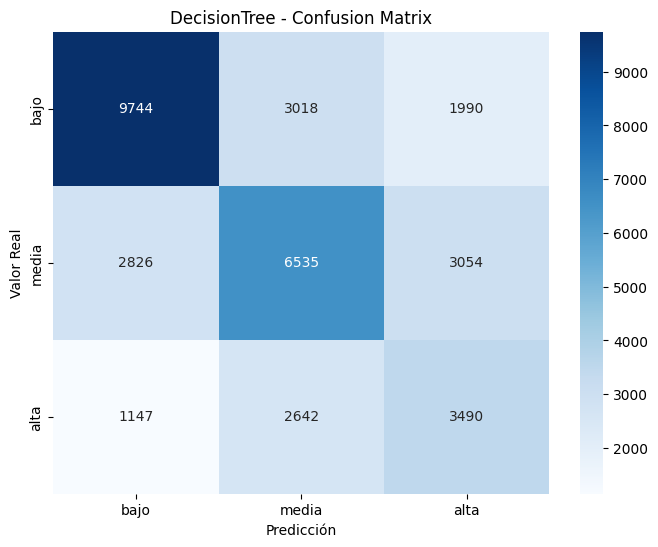


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.35      0.33      0.34     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.35      0.33      0.34     34446



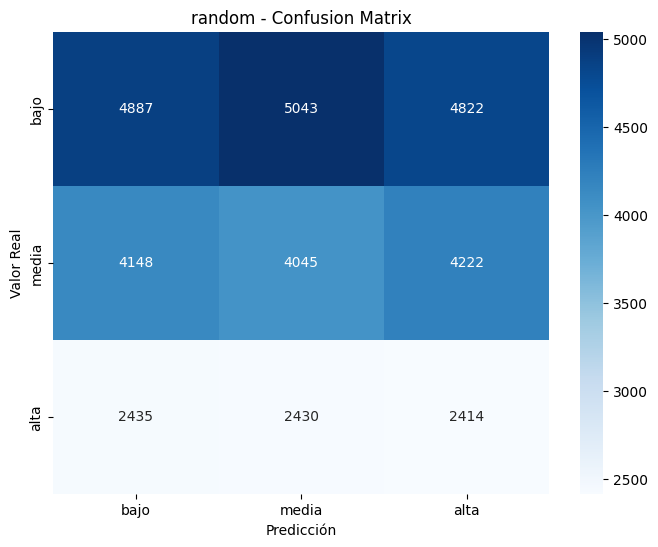

[0.49333973 0.50666027]
error shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (82,) and arg 1 with shape (2,).


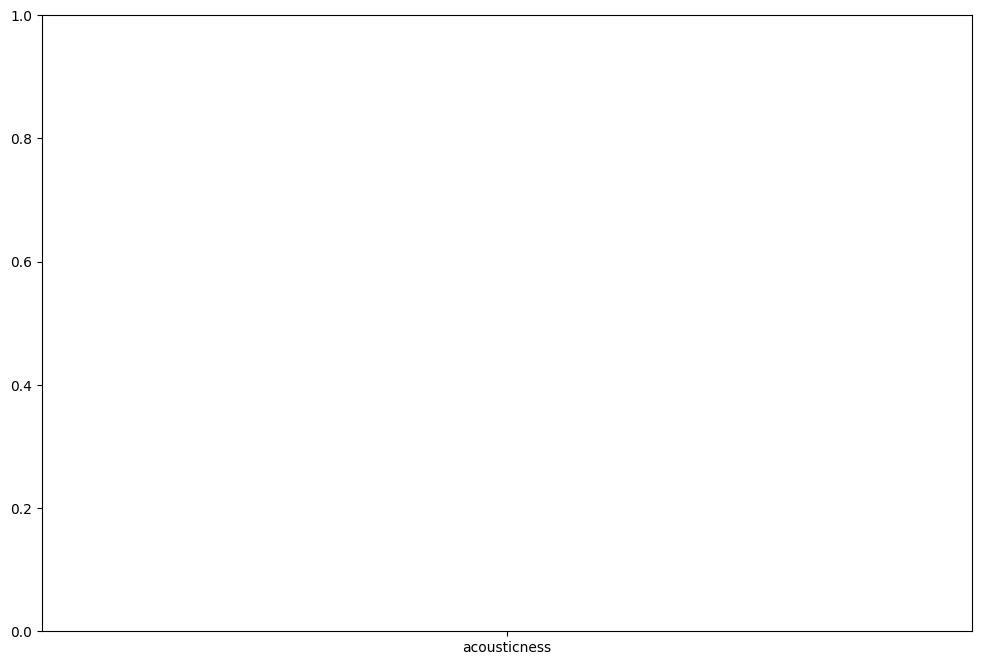

In [32]:
from sklearn.decomposition import PCA
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
pca = PCA(n_components=2)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

X_train_reduce = pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)
smote = SMOTE(sampling_strategy='auto')
X_train_reduce,y_train_reduce = smote.fit_resample(X_train_reduce,y_train_reduce)
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
     
    
}
param_grids = {
   
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

# PCA n=85%

Fitting 5 folds for each of 9 candidates, totalling 45 fits

RandomForest
Best params: {'max_depth': 20, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.62      0.51      0.56     14752
           1       0.43      0.42      0.43     12415
           2       0.34      0.48      0.40      7279

    accuracy                           0.47     34446
   macro avg       0.47      0.47      0.46     34446
weighted avg       0.49      0.47      0.48     34446



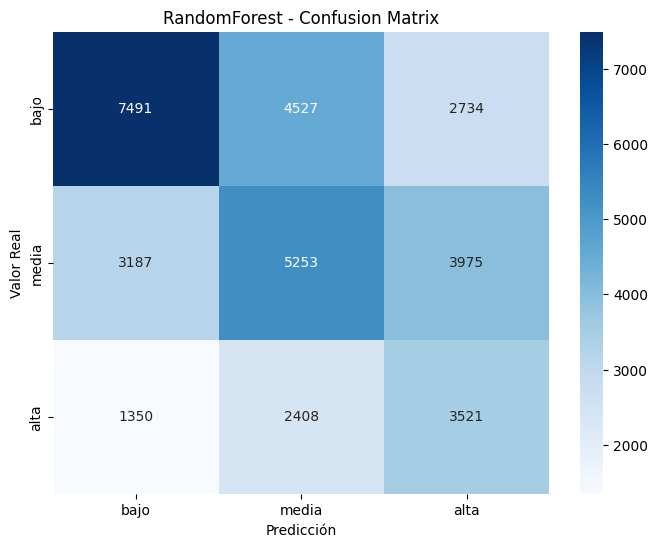


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.34     34446
   macro avg       0.34      0.34      0.33     34446
weighted avg       0.36      0.34      0.34     34446



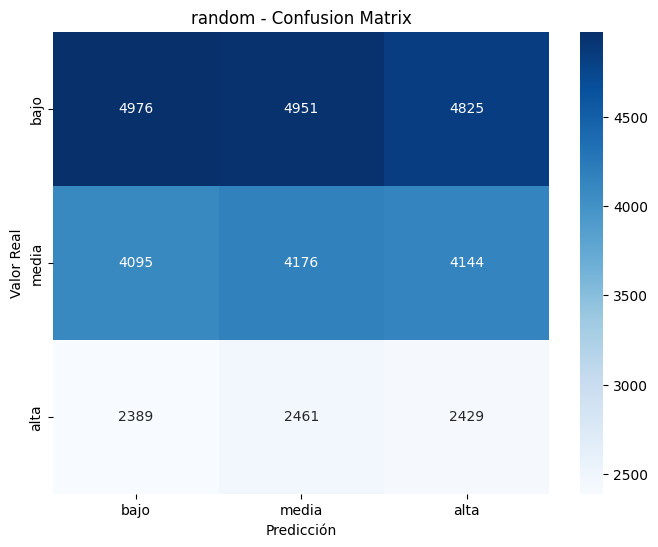

[1.]


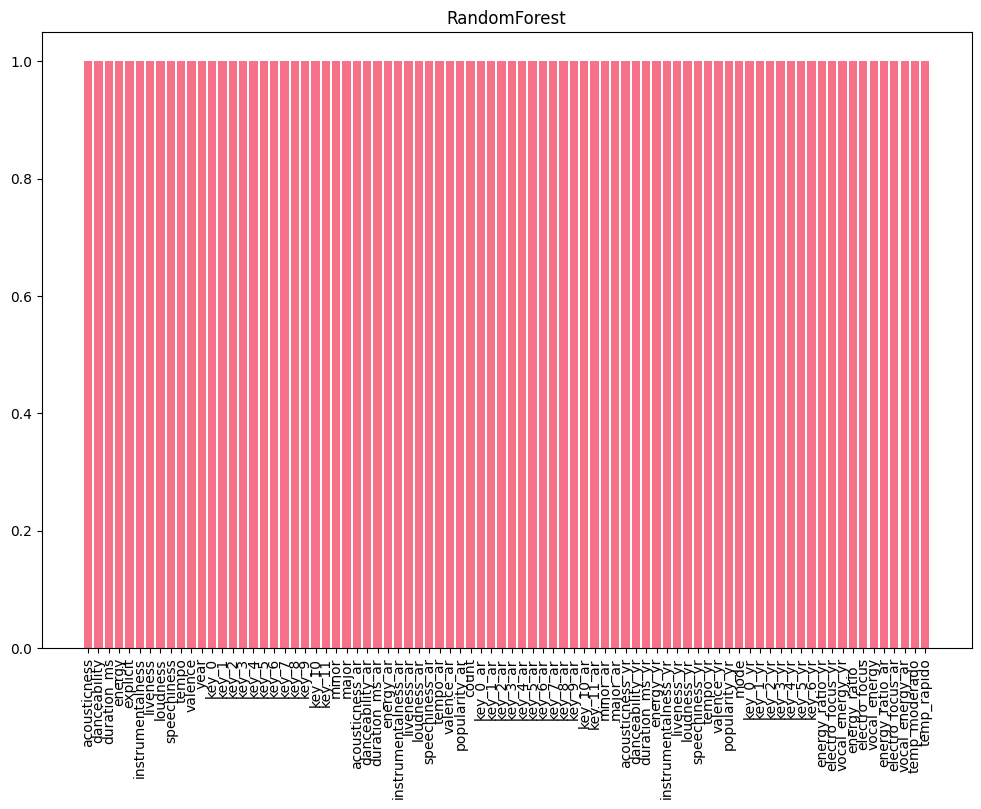

Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 300}
              precision    recall  f1-score   support

           0       0.64      0.54      0.58     14752
           1       0.44      0.44      0.44     12415
           2       0.37      0.48      0.42      7279

    accuracy                           0.49     34446
   macro avg       0.48      0.49      0.48     34446
weighted avg       0.51      0.49      0.50     34446



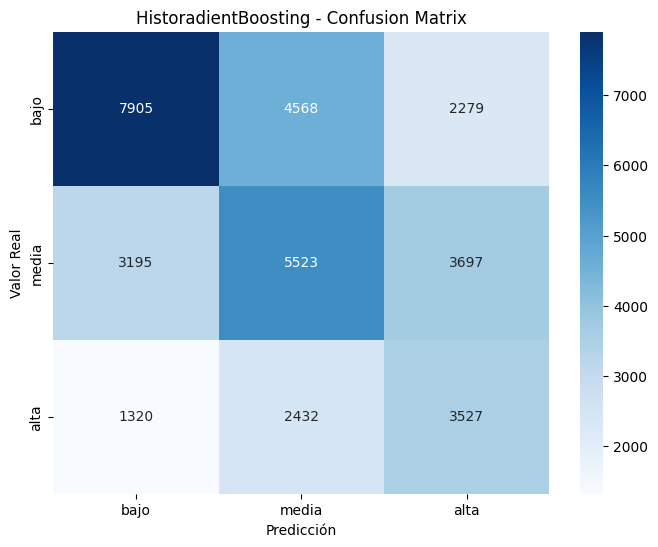


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.34     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.34      0.34     34446



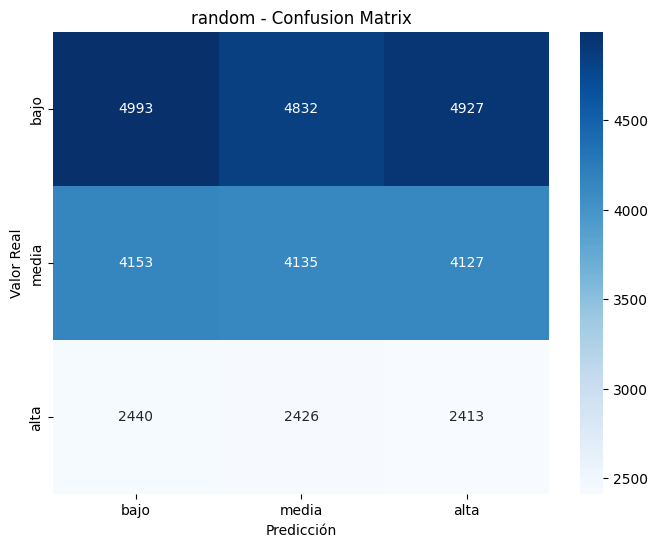

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 3, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.63      0.54      0.58     14752
           1       0.44      0.41      0.42     12415
           2       0.37      0.51      0.43      7279

    accuracy                           0.49     34446
   macro avg       0.48      0.49      0.48     34446
weighted avg       0.51      0.49      0.49     34446



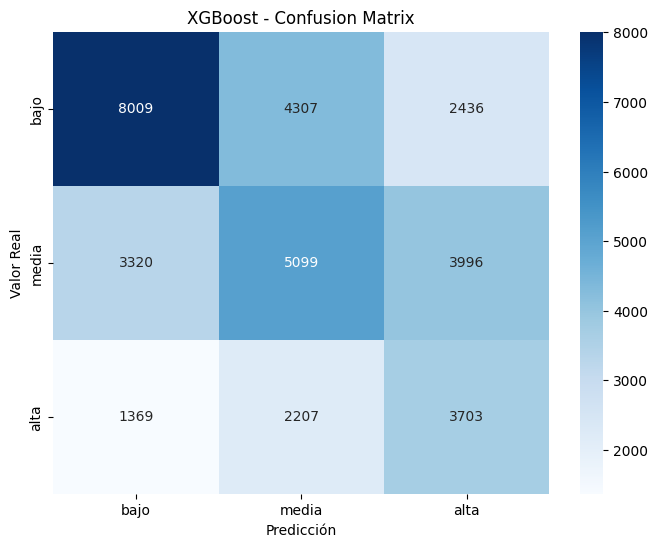


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.35      0.33      0.34     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.36      0.33      0.34     34446



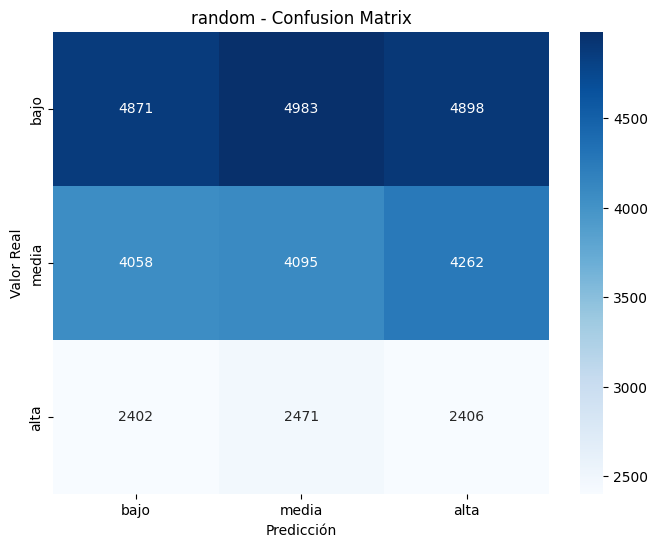

[1.]


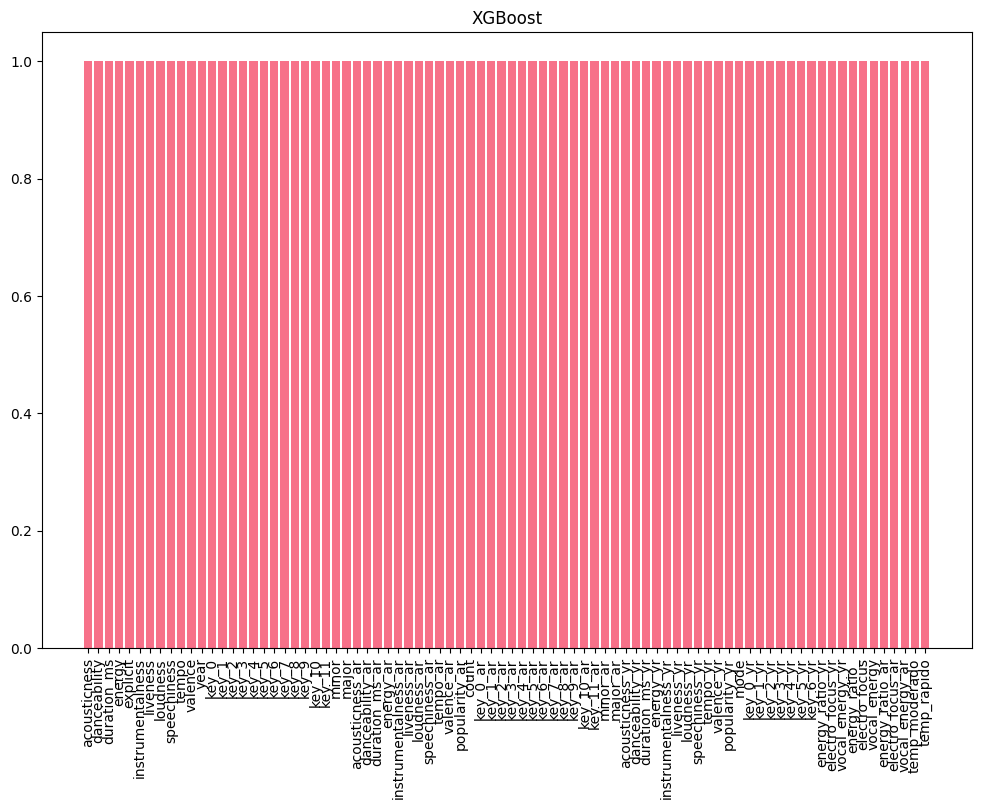

Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.62      0.53      0.57     14752
           1       0.43      0.35      0.38     12415
           2       0.33      0.55      0.42      7279

    accuracy                           0.47     34446
   macro avg       0.46      0.47      0.46     34446
weighted avg       0.49      0.47      0.47     34446



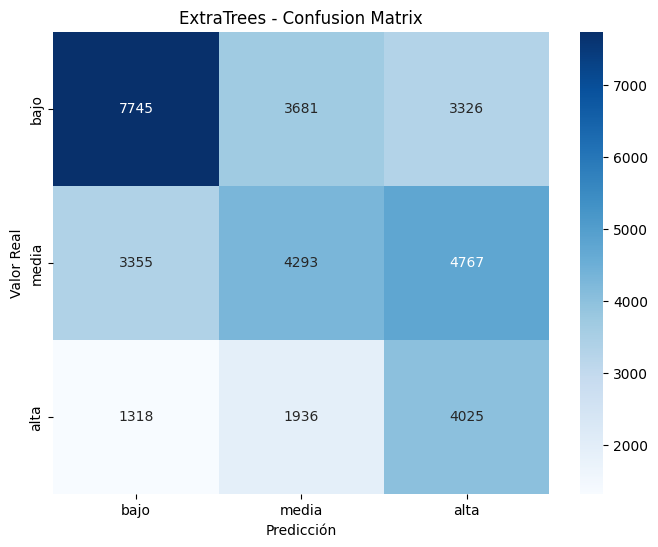


random
              precision    recall  f1-score   support

           0       0.42      0.34      0.37     14752
           1       0.36      0.33      0.34     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



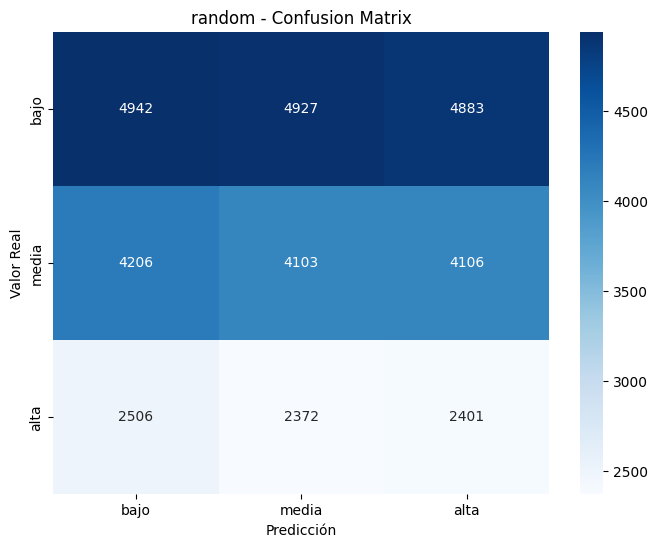

[1.]


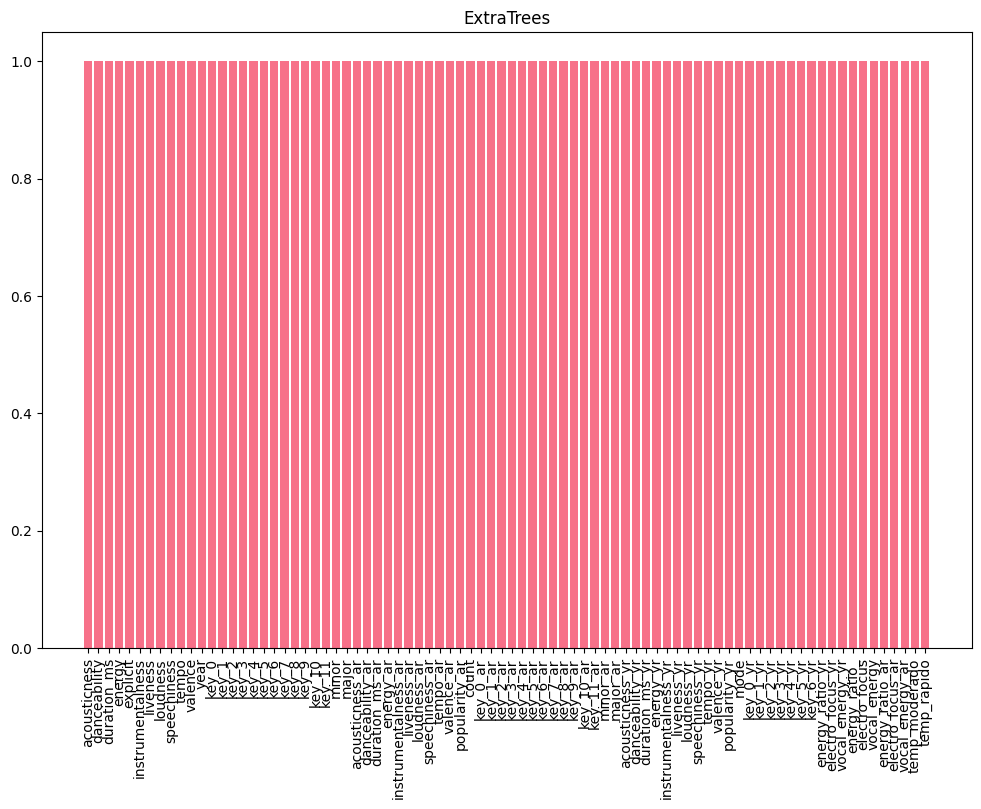

Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.64      0.53      0.58     14752
           1       0.44      0.43      0.43     12415
           2       0.37      0.51      0.43      7279

    accuracy                           0.49     34446
   macro avg       0.48      0.49      0.48     34446
weighted avg       0.51      0.49      0.49     34446



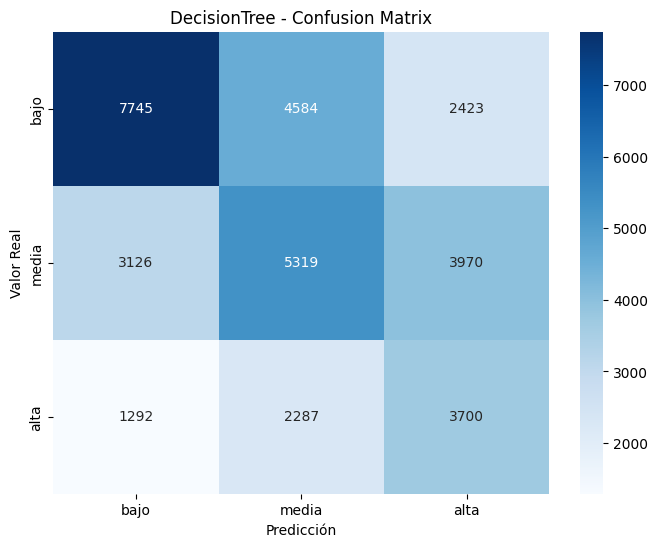


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.34     34446
   macro avg       0.34      0.33      0.33     34446
weighted avg       0.36      0.34      0.34     34446



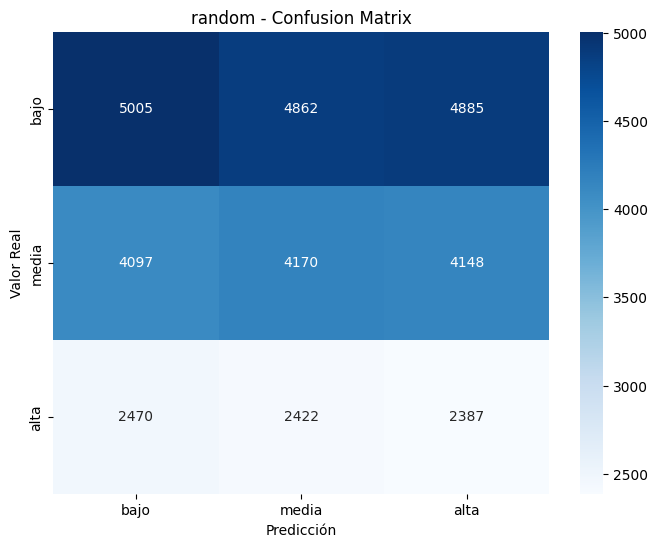

[1.]


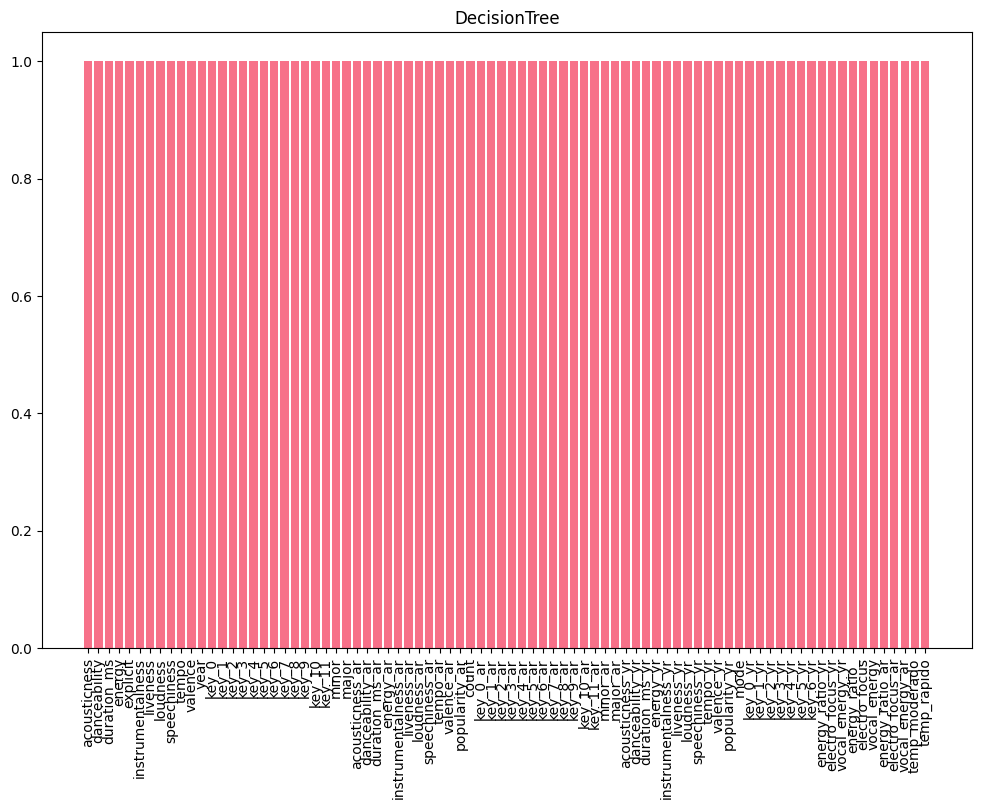

In [33]:
from sklearn.decomposition import PCA
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
pca = PCA(n_components=0.85)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

X_train_reduce = pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)
smote = SMOTE(sampling_strategy='auto')
X_train_reduce,y_train_reduce = smote.fit_resample(X_train_reduce,y_train_reduce)
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END ................................................C=1; total time=19.1min
[CV] END ................................................C=1; total time=19.4min
[CV] END ................................................C=1; total time=19.4min
[CV] END ................................................C=1; total time=19.7min
[CV] END ................................................C=1; total time=21.0min

SVC
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.91      0.93      0.92     14752
           1       0.76      0.80      0.78     12415
           2       0.78      0.69      0.73      7279

    accuracy                           0.83     34446
   macro avg       0.82      0.81      0.81     34446
weighted avg       0.83      0.83      0.83     34446



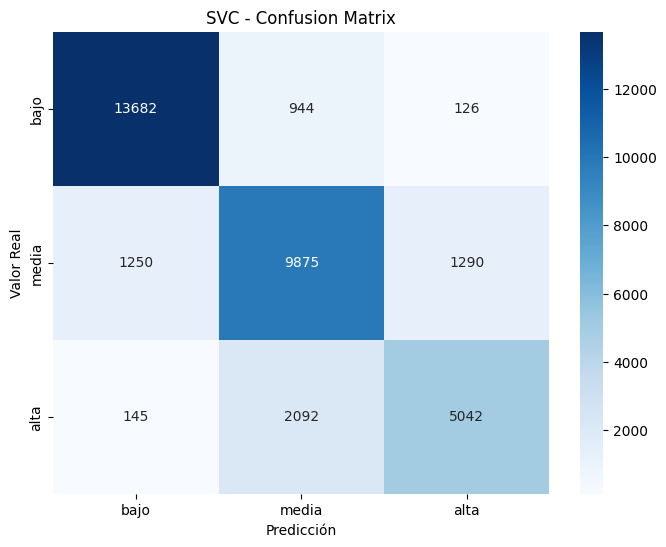


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.33      0.25      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



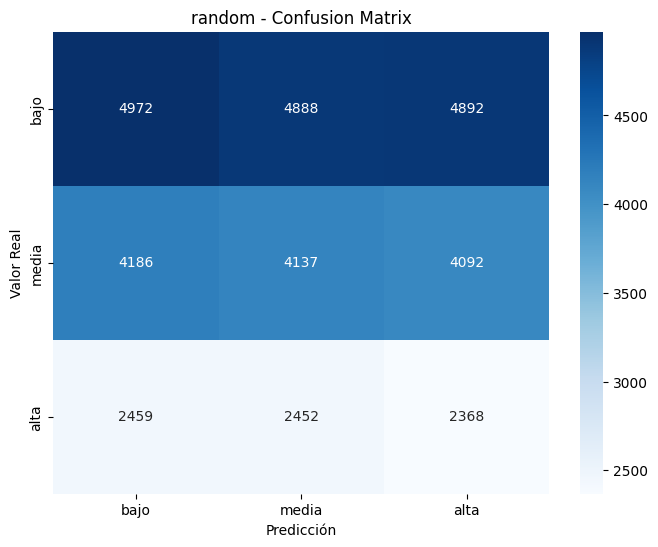

error 'SVC' object has no attribute 'feature_importances_'


In [6]:
selector = SelectKBest(score_func=f_classif,k=10)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
smote = SMOTE(sampling_strategy='auto')
X_train_reduce,y_train_reduce = smote.fit_resample(X_train_reduce,y_train_reduce)
models = {
    "SVC":SVC(kernel='rbf')
}
param_grids = {
    'SVC':{
        "C":[1]
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END ................................................C=1; total time=40.5min
[CV] END ................................................C=1; total time=41.1min
[CV] END ................................................C=1; total time=41.2min
[CV] END ................................................C=1; total time=41.7min
[CV] END ................................................C=1; total time=41.9min

SVC
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.66      0.45      0.54     14752
           1       0.49      0.21      0.29     12415
           2       0.25      0.65      0.36      7279

    accuracy                           0.41     34446
   macro avg       0.47      0.44      0.40     34446
weighted avg       0.51      0.41      0.41     34446



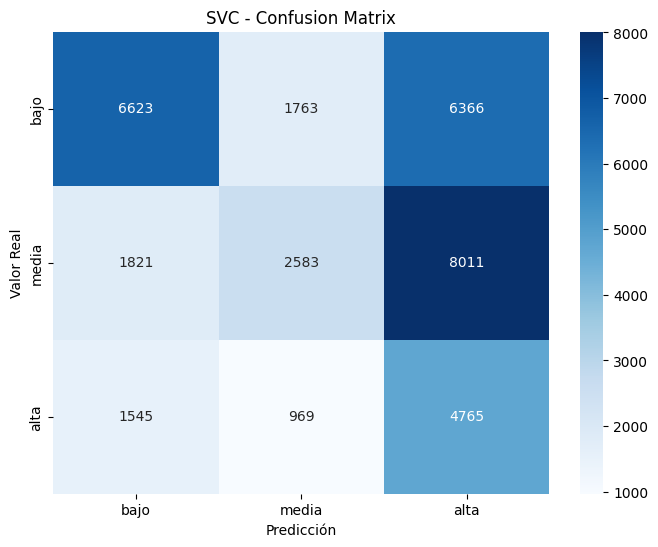


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.35      0.33      0.34     12415
           2       0.21      0.34      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.35      0.33      0.34     34446



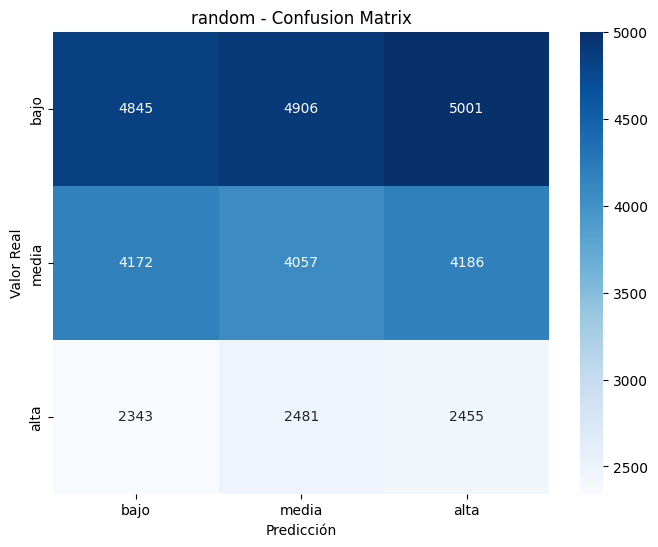

error 'SVC' object has no attribute 'feature_importances_'


In [8]:
from sklearn.decomposition import PCA
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
pca = PCA(n_components=2)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

X_train_reduce = pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)
smote = SMOTE(sampling_strategy='auto')
X_train_reduce,y_train_reduce = smote.fit_resample(X_train_reduce,y_train_reduce)
models = {
      "SVC":SVC(kernel='rbf')
    
}
param_grids = {
    'SVC':{
        "C":[1]
    }
    
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END ................................................C=1; total time=   0.6s
[CV] END ................................................C=1; total time=   0.6s
[CV] END ................................................C=1; total time=   0.6s
[CV] END ................................................C=1; total time=   0.6s
[CV] END ................................................C=1; total time=   0.6s

LogisticRegression_OVO
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.43      1.00      0.60     14752
           1       0.00      0.00      0.00     12415
           2       0.00      0.00      0.00      7279

    accuracy                           0.43     34446
   macro avg       0.14      0.33      0.20     34446
weighted avg       0.18      0.43      0.26     34446



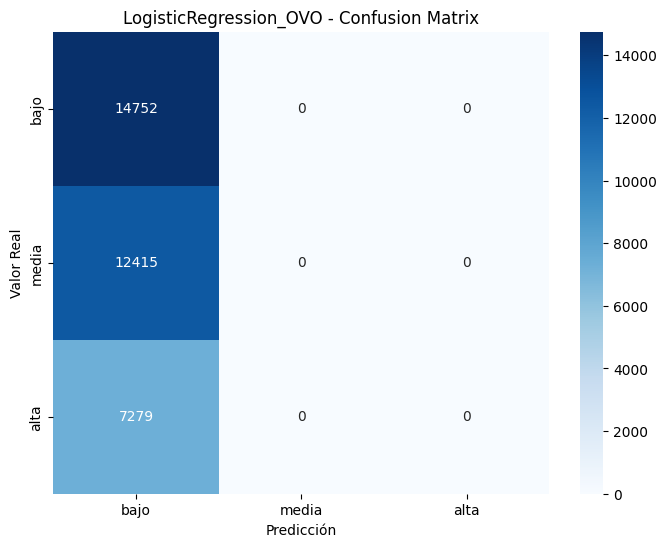


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.38     14752
           1       0.37      0.34      0.35     12415
           2       0.22      0.35      0.27      7279

    accuracy                           0.34     34446
   macro avg       0.34      0.34      0.33     34446
weighted avg       0.36      0.34      0.34     34446



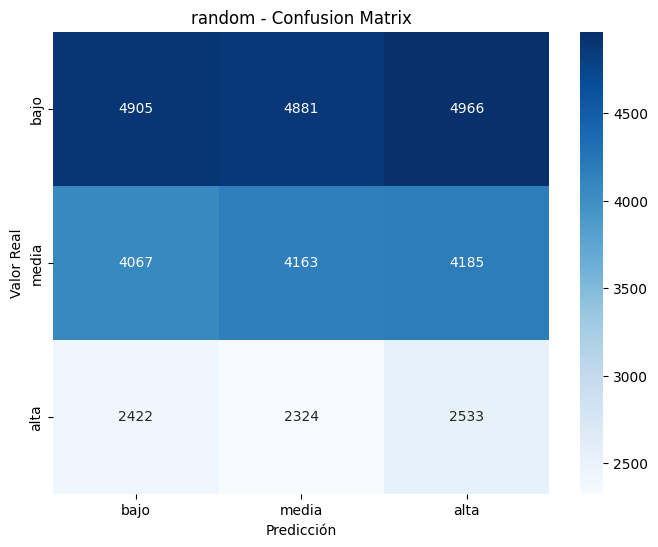

error 'LogisticRegression' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END ................................................C=1; total time=   0.3s
[CV] END ................................................C=1; total time=   0.3s
[CV] END ................................................C=1; total time=   0.3s
[CV] END ................................................C=1; total time=   0.3s
[CV] END ................................................C=1; total time=   0.3s

LogisticRegression_OVR
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.43      1.00      0.60     14752
           1       0.00      0.00      0.00     12415
           2       0.00      0.00      0.00      7279

    accuracy                           0.43     34446
   macro avg       0.14      0.33      0.20     34446
weighted avg       0.18      0.43      0.26     34446



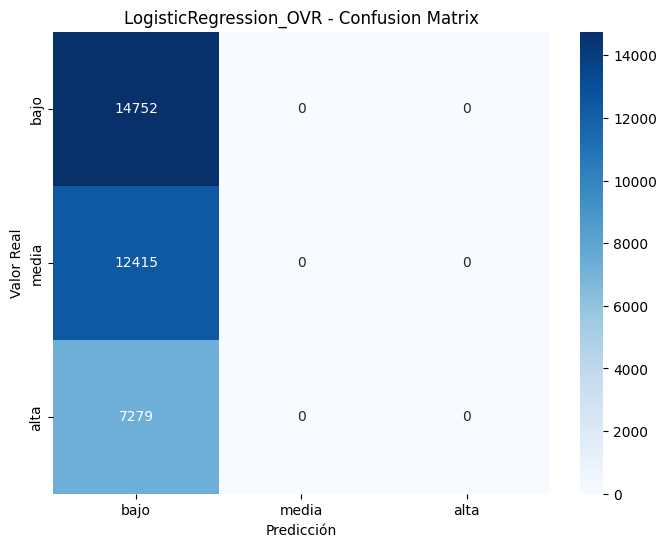


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.34      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



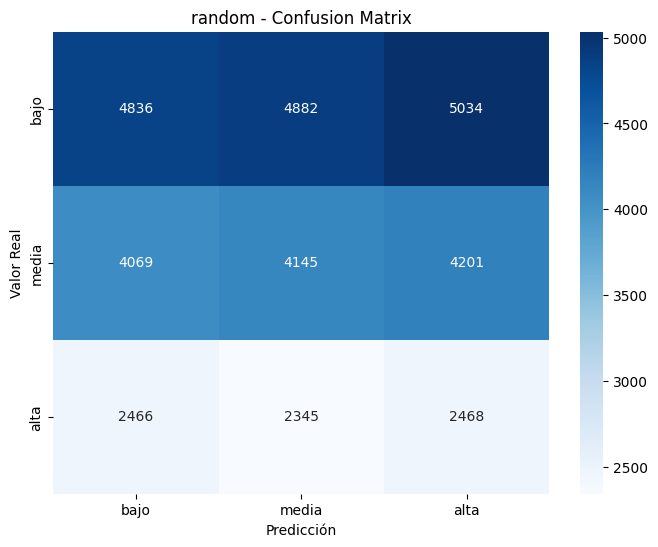

error 'LogisticRegression' object has no attribute 'feature_importances_'


In [16]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
pca = PCA(n_components=0.85)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

X_train_reduce = pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)

models = {
      "LogisticRegression_OVO":LogisticRegression(multi_class='multinomial'),
      "LogisticRegression_OVR":LogisticRegression(multi_class='ovr')
}
param_grids = {
    'LogisticRegression_OVO':{
        "C":[1]
    },'LogisticRegression_OVR':{
        "C":[1]
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END ................................................C=1; total time=   3.1s
[CV] END ................................................C=1; total time=   3.1s
[CV] END ................................................C=1; total time=   3.1s
[CV] END ................................................C=1; total time=   3.2s
[CV] END ................................................C=1; total time=   3.2s

LogisticRegression_OVO
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.91      0.92      0.92     14752
           1       0.75      0.83      0.79     12415
           2       0.83      0.65      0.73      7279

    accuracy                           0.83     34446
   macro avg       0.83      0.80      0.81     34446
weighted avg       0.84      0.83      0.83     34446



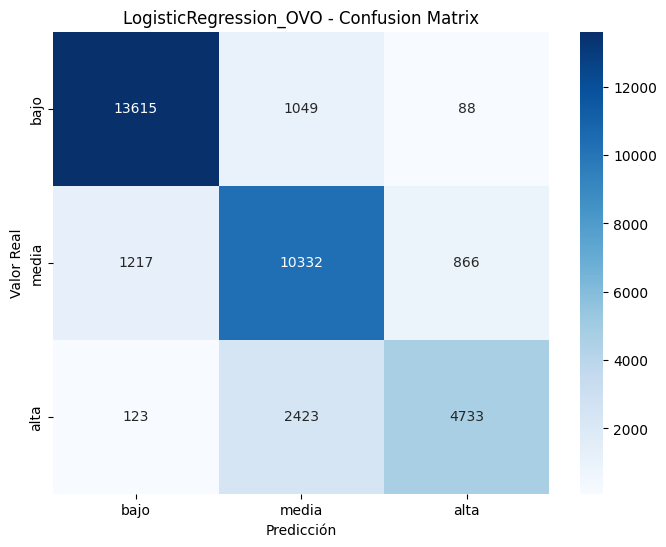


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.36      0.33      0.34     34446



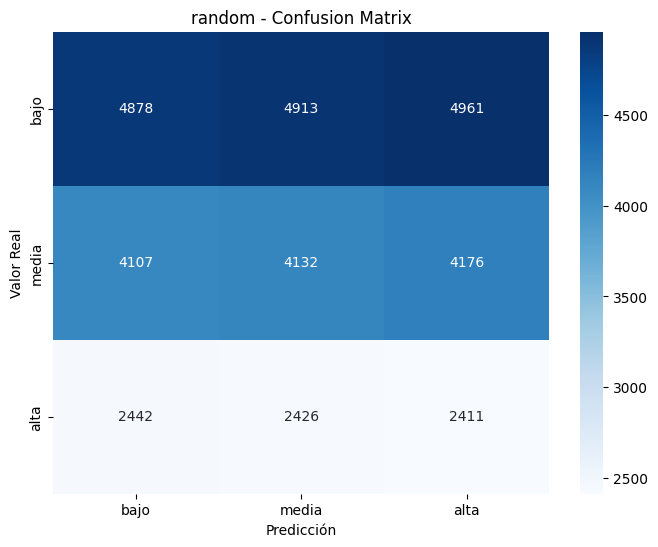

error 'LogisticRegression' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END ................................................C=1; total time=   7.8s
[CV] END ................................................C=1; total time=   8.1s
[CV] END ................................................C=1; total time=   8.3s
[CV] END ................................................C=1; total time=   6.4s
[CV] END ................................................C=1; total time=   6.4s

LogisticRegression_OVR
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     14752
           1       0.74      0.83      0.79     12415
           2       0.84      0.61      0.71      7279

    accuracy                           0.83     34446
   macro avg       0.83      0.79      0.80     34446
weighted avg       0.83      0.83      0.83     34446



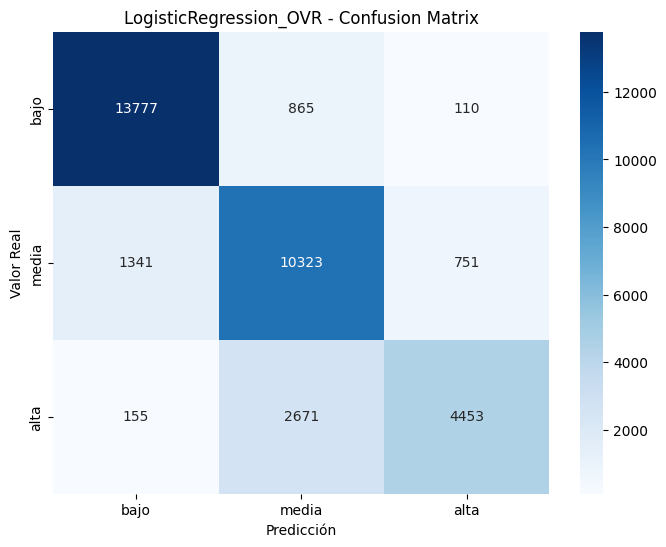


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.35      0.34      0.35     12415
           2       0.21      0.32      0.25      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.32     34446
weighted avg       0.36      0.33      0.34     34446



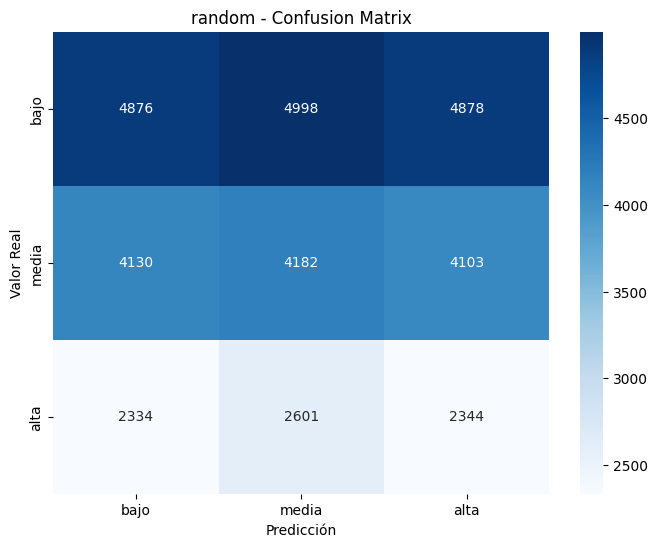

error 'LogisticRegression' object has no attribute 'feature_importances_'


In [12]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()
selector = SelectKBest(score_func=f_classif,k=30)
X_new = selector.fit_transform(_X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)



models = {
      "LogisticRegression_OVO":LogisticRegression(multi_class='multinomial'),
      "LogisticRegression_OVR":LogisticRegression(multi_class='ovr')
}
param_grids = {
    'LogisticRegression_OVO':{
        "C":[1]
    },'LogisticRegression_OVR':{
        "C":[1]
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END ................................................C=1; total time=   2.2s
[CV] END ................................................C=1; total time=   2.2s
[CV] END ................................................C=1; total time=   2.2s
[CV] END ................................................C=1; total time=   2.3s
[CV] END ................................................C=1; total time=   2.4s

LogisticRegression_OVO
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.91      0.92      0.92     14752
           1       0.74      0.83      0.79     12415
           2       0.83      0.64      0.72      7279

    accuracy                           0.83     34446
   macro avg       0.83      0.80      0.81     34446
weighted avg       0.83      0.83      0.83     34446



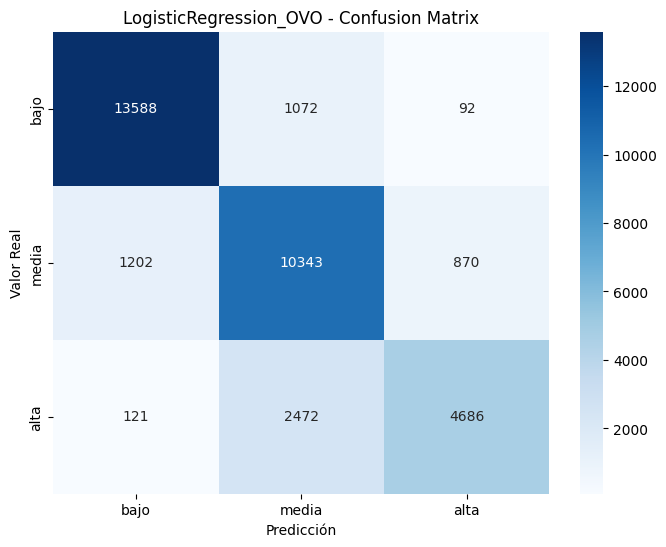


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.38     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



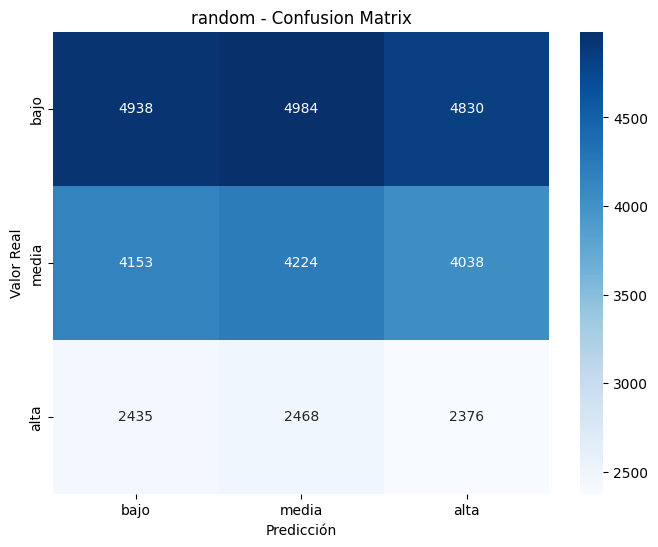

error 'LogisticRegression' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END ................................................C=1; total time=   2.1s
[CV] END ................................................C=1; total time=   2.3s
[CV] END ................................................C=1; total time=   2.0s
[CV] END ................................................C=1; total time=   2.1s
[CV] END ................................................C=1; total time=   2.1s

LogisticRegression_OVR
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     14752
           1       0.74      0.83      0.78     12415
           2       0.83      0.62      0.71      7279

    accuracy                           0.83     34446
   macro avg       0.83      0.79      0.80     34446
weighted avg       0.83      0.83      0.83     34446



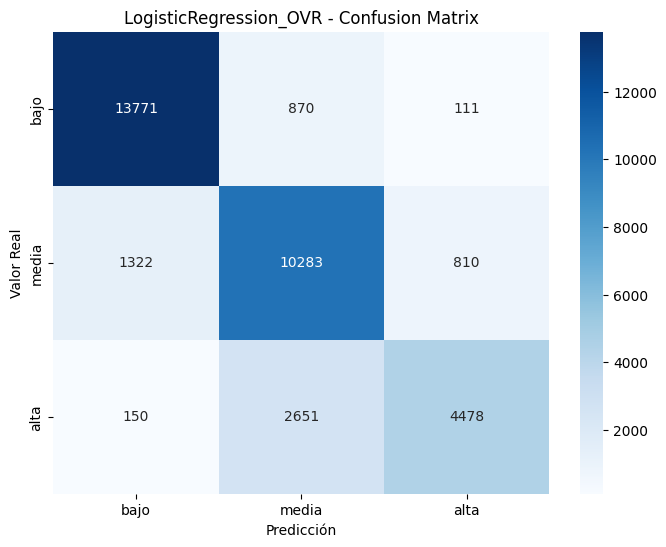


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.38     14752
           1       0.36      0.34      0.35     12415
           2       0.22      0.34      0.26      7279

    accuracy                           0.34     34446
   macro avg       0.34      0.34      0.33     34446
weighted avg       0.36      0.34      0.34     34446



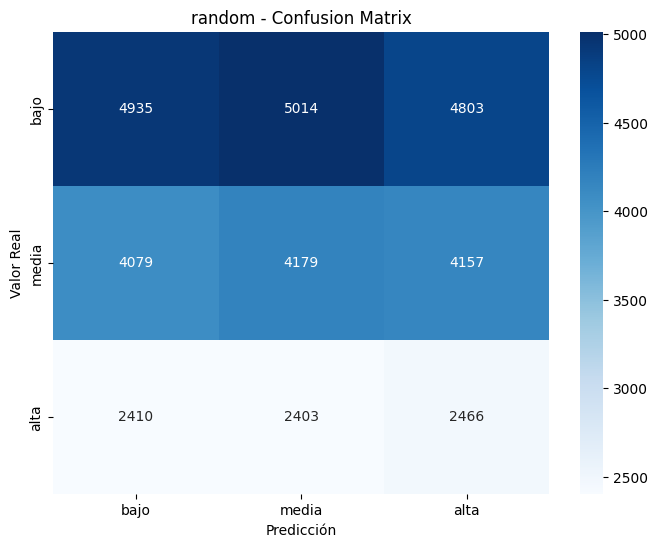

error 'LogisticRegression' object has no attribute 'feature_importances_'


In [14]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()
selector = SelectKBest(score_func=f_classif,k=20)
X_new = selector.fit_transform(_X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)



models = {
      "LogisticRegression_OVO":LogisticRegression(multi_class='multinomial'),
      "LogisticRegression_OVR":LogisticRegression(multi_class='ovr')
}
param_grids = {
    'LogisticRegression_OVO':{
        "C":[1]
    },'LogisticRegression_OVR':{
        "C":[1]
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END ................................................C=1; total time=   2.2s
[CV] END ................................................C=1; total time=   2.2s
[CV] END ................................................C=1; total time=   2.4s
[CV] END ................................................C=1; total time=   2.5s
[CV] END ................................................C=1; total time=   2.9s

LogisticRegression_OVO
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.91      0.92      0.92     14752
           1       0.75      0.83      0.79     12415
           2       0.83      0.65      0.73      7279

    accuracy                           0.83     34446
   macro avg       0.83      0.80      0.81     34446
weighted avg       0.83      0.83      0.83     34446



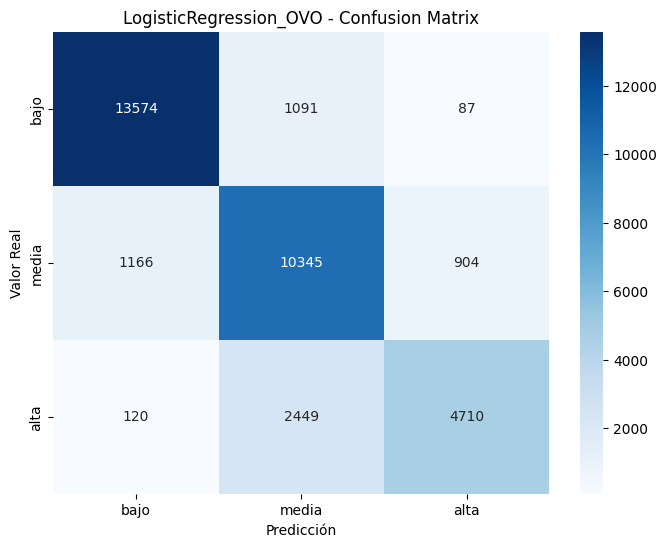


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.38     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.32      0.25      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



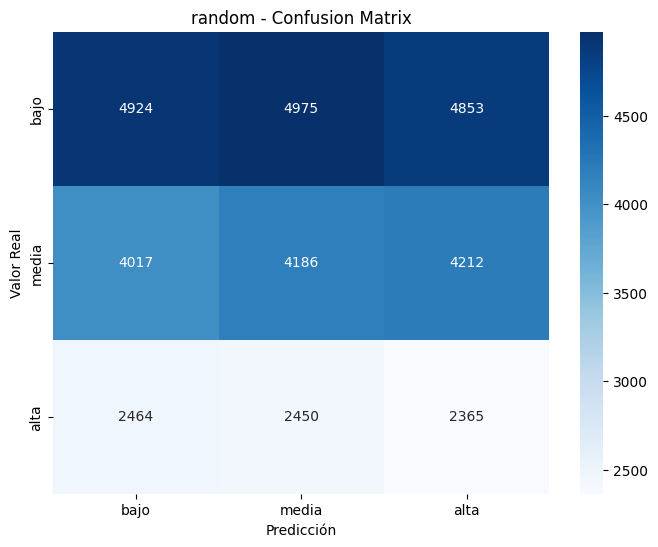

error 'LogisticRegression' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END ................................................C=1; total time=   2.6s
[CV] END ................................................C=1; total time=   2.6s
[CV] END ................................................C=1; total time=   2.7s
[CV] END ................................................C=1; total time=   2.7s
[CV] END ................................................C=1; total time=   2.7s

LogisticRegression_OVR
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.91      0.93      0.92     14752
           1       0.74      0.83      0.78     12415
           2       0.83      0.61      0.70      7279

    accuracy                           0.83     34446
   macro avg       0.83      0.79      0.80     34446
weighted avg       0.83      0.83      0.82     34446



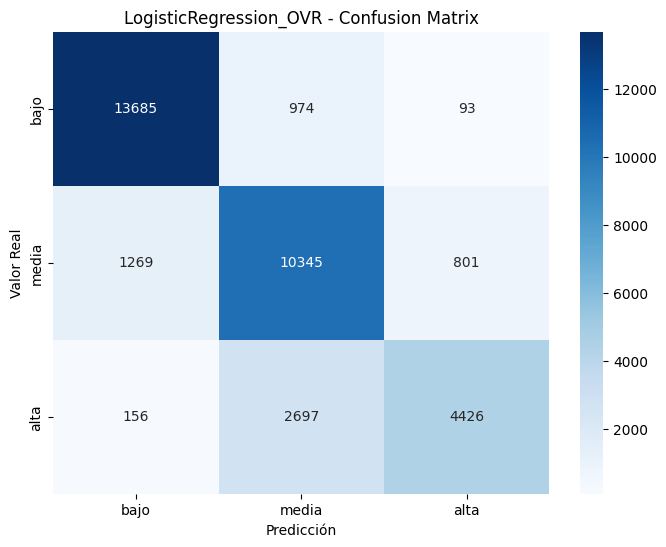


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.34      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.34     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.34      0.34     34446



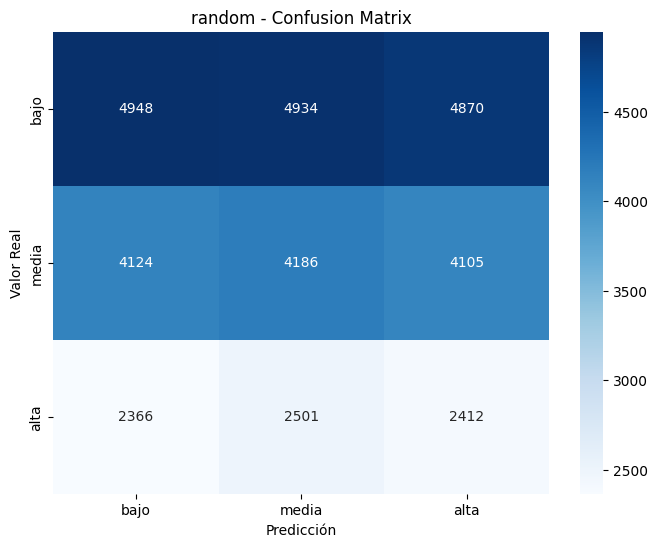

error 'LogisticRegression' object has no attribute 'feature_importances_'


In [15]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()
selector = SelectKBest(score_func=f_classif,k=10)
X_new = selector.fit_transform(_X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)



models = {
      "LogisticRegression_OVO":LogisticRegression(multi_class='multinomial'),
      "LogisticRegression_OVR":LogisticRegression(multi_class='ovr')
}
param_grids = {
    'LogisticRegression_OVO':{
        "C":[1]
    },'LogisticRegression_OVR':{
        "C":[1]
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time=  56.1s
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time=  56.6s
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time=  57.0s
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time=  58.3s
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time=  58.5s
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time=  59.2s
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time=  59.6s
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time= 1.0min
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time=  47.9s
[CV] END .................algorithm=ball_tree, n_neighbors=7; total time=  49.4s
[CV] END .................algorithm=ball_tree, n_neighbors=7; total time=  49.7s
[CV] END .................algorithm=ball_tree, n

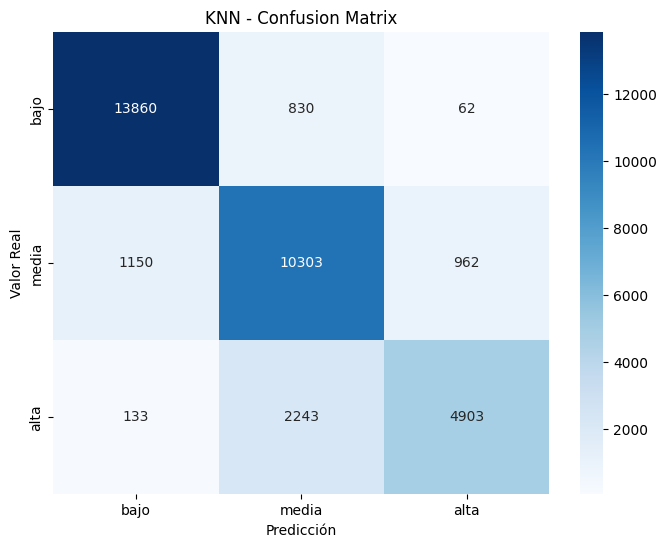


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



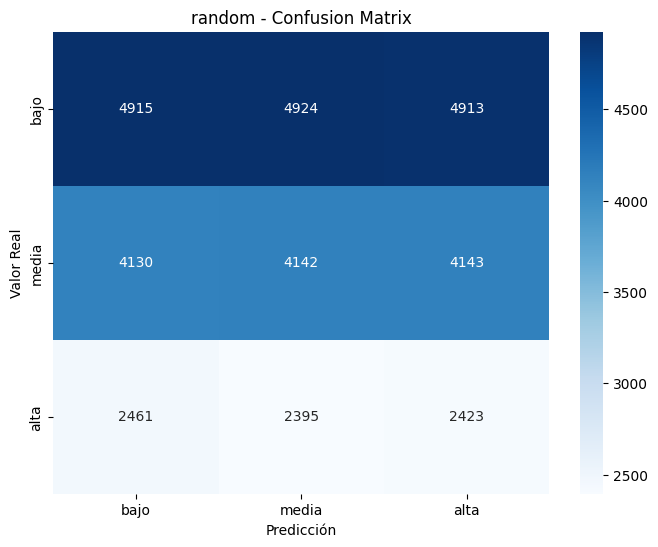

error 'KNeighborsClassifier' object has no attribute 'feature_importances_'


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()
selector = SelectKBest(score_func=f_classif,k=10)
X_new = selector.fit_transform(_X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)



models = {
      "KNN":KNeighborsClassifier()
}
param_grids = {
    'KNN':{
        "n_neighbors":[3,5,7,9],
        'algorithm':['ball_tree','auto','brute']
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time= 3.1min
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time= 3.2min
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time= 3.2min
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time= 3.2min
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time= 3.2min
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time= 3.3min
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time= 3.3min
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time= 3.3min
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time= 3.2min
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time= 3.2min
[CV] END .................algorithm=ball_tree, n_neighbors=7; total time= 3.3min
[CV] END .................algorithm=ball_tree, n

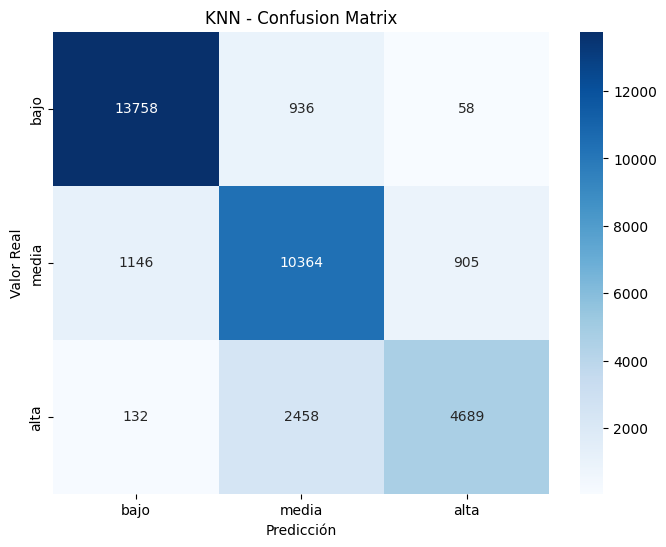


random
              precision    recall  f1-score   support

           0       0.43      0.34      0.38     14752
           1       0.36      0.33      0.34     12415
           2       0.21      0.33      0.26      7279

    accuracy                           0.34     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.34      0.34     34446



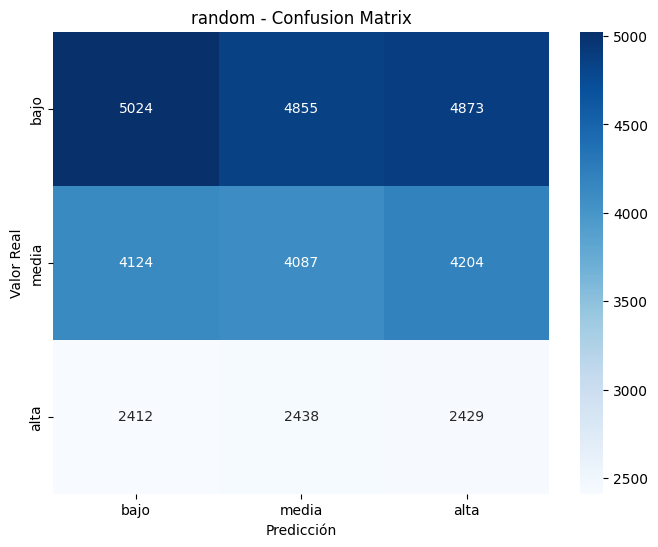

error 'KNeighborsClassifier' object has no attribute 'feature_importances_'


In [18]:
from sklearn.neighbors import KNeighborsClassifier
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()
selector = SelectKBest(score_func=f_classif,k=20)
X_new = selector.fit_transform(_X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)



models = {
      "KNN":KNeighborsClassifier()
}
param_grids = {
    'KNN':{
        "n_neighbors":[3,5,7,9],
        'algorithm':['ball_tree','auto','brute']
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time= 5.8min
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time= 5.8min
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time= 5.8min
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time= 5.8min
[CV] END .................algorithm=ball_tree, n_neighbors=3; total time= 5.9min
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time= 6.1min
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time= 6.1min
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time= 6.1min
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time= 5.3min
[CV] END .................algorithm=ball_tree, n_neighbors=5; total time= 5.3min
[CV] END .................algorithm=ball_tree, n_neighbors=7; total time= 5.4min
[CV] END .................algorithm=ball_tree, n

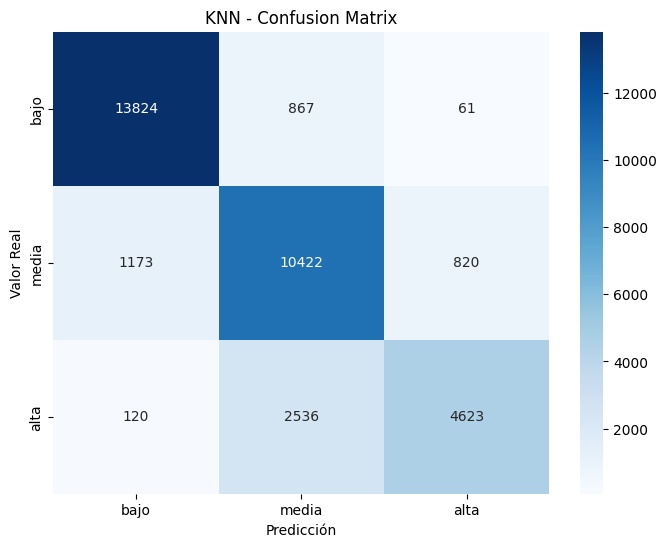


random
              precision    recall  f1-score   support

           0       0.43      0.33      0.37     14752
           1       0.36      0.33      0.35     12415
           2       0.21      0.33      0.25      7279

    accuracy                           0.33     34446
   macro avg       0.33      0.33      0.33     34446
weighted avg       0.36      0.33      0.34     34446



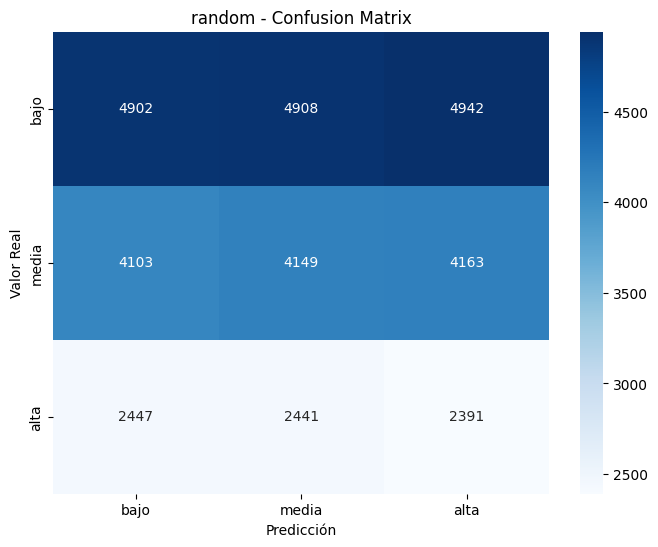

error 'KNeighborsClassifier' object has no attribute 'feature_importances_'


: 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()
selector = SelectKBest(score_func=f_classif,k=30)
X_new = selector.fit_transform(_X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)



models = {
      "KNN":KNeighborsClassifier()
}
param_grids = {
    'KNN':{
        "n_neighbors":[3,5,7,9],
        'algorithm':['ball_tree','auto','brute']
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,3,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_